

### Dữ liệu

| Thành phần | Mô tả |
|---|---|
| **Training** | File `sales.csv` - 3 cột: `Date`, `Revenue`, `COGS` - phủ liên tục từ `2012-07-04` đến `2022-12-31` (3,833 ngày) |
| **Test** | File `sample_submission.csv` - 548 dòng, mỗi dòng 1 ngày trong khoảng 01/01/2023 -> 01/07/2024 |
| **Bảng phụ** | 12 bảng (promotions, inventory, returns, customers, web_traffic, ...) - tất cả dừng ở 2022, chỉ dùng để rút ra pattern lặp lại |

### Hàm mục tiêu

Hàm chấm điểm của cuộc thi là **MAE** (Mean Absolute Error), **RMSE** và **R²**, tổng hợp trên cả hai biến Revenue và COGS.

### Thách thức đặc biệt

1. **Horizon dài 18 tháng** - vượt xa khả năng extrapolate của các mô hình đơn giản, khiến feature lag ($y_{t-1}, y_{t-7}$) không còn truy cập được
2. **Regime drift mạnh** - phân phối sau 2020 khác xa 2012-2018 cả về mean lẫn variance
3. **Calibration bias** - mô hình học trên log-space có xu hướng dự đoán thấp hơn thực tế

### Phương pháp tiếp cận

Pipeline gồm 4 bước chính:

```
Feature Engineering (Calendar-Only)
        ↓
3 mô hình nền (Ridge + LightGBM + Prophet) + 4 Q-Specialists
        ↓
Ensemble phân tầng 3 lớp  
        ↓
Calibration -> Submission
```

---

## Mục lục

1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Feature Engineering (Calendar-Only)](#3)
4. [Validation Strategy (3 Temporal Folds)](#4)
5. [Model 1: Ridge Regression](#5)
6. [Model 2: LightGBM with Sample Weighting](#6)
7. [Model 3: Prophet](#7)
8. [Q-Specialist Models](#8)
9. [Tiered Ensemble](#9)
10. [Final Prediction & Submission](#10)

---
<a id='1'></a>
## 1. Setup & Data Loading

### Thư viện sử dụng

Pipeline sử dụng 3 họ mô hình chính:
- **scikit-learn** (`Ridge`) - mô hình tuyến tính tham số
- **LightGBM** (`lgb`) - mô hình cây gradient boosting
- **Prophet** - mô hình phân rã chuỗi thời gian của Meta

Ngoài ra, `statsmodels` được dùng cho phân tích EDA (seasonal decomposition, ADF test, ACF/PACF) và `scipy` cho tối ưu calibration.

In [20]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import lightgbm as lgb
from prophet import Prophet

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (16, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports loaded successfully.')

All imports loaded successfully.


### 1.2 Đọc dữ liệu

Dữ liệu chính từ file `sales.csv` gồm 3 cột: `Date`, `Revenue`, `COGS`, phủ liên tục từ 04/07/2012 đến 31/12/2022. File `sample_submission.csv` định nghĩa 548 ngày cần dự báo.

**Kiểm tra chất lượng:** Xác nhận không có missing values và không có ngày bị khuyết trong chuỗi training - đây là điều kiện thuận lợi cho modeling.

In [21]:
RAW_DIR = '../data/raw'
ANALYTICAL_DIR = f'{RAW_DIR}/analytical'

sales = pd.read_csv(f'{ANALYTICAL_DIR}/sales.csv', parse_dates=['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)

submission_template = pd.read_csv(f'{ANALYTICAL_DIR}/sample_submission.csv', parse_dates=['Date'])

print(f'Training data : {sales["Date"].min().date()} -> {sales["Date"].max().date()}  ({len(sales):,} days)')
print(f'Forecast dates: {submission_template["Date"].min().date()} -> {submission_template["Date"].max().date()}  ({len(submission_template):,} days)')
print()

print('Missing values:', sales.isnull().sum().to_dict())
date_range = pd.date_range(start=sales['Date'].min(), end=sales['Date'].max(), freq='D')
missing_dates = date_range.difference(sales['Date'])
print(f'Missing dates in training: {len(missing_dates)}')
print()
sales.head()

Training data : 2012-07-04 -> 2022-12-31  (3,833 days)
Forecast dates: 2023-01-01 -> 2024-07-01  (548 days)

Missing values: {'Date': 0, 'Revenue': 0, 'COGS': 0}
Missing dates in training: 0



,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


---
<a id='2'></a>
## 2. Exploratory Data Analysis (EDA) For Forecasting

Trước khi quyết định mô hình, cần hình dung rõ dữ liệu đang nói lên điều gì. Phân tích EDA nhằm trả lời **6 câu hỏi then chốt**:

1. **Dữ liệu có đồng nhất theo thời gian?** -> Xác định regime drift
2. **Shape mùa vụ có ổn định qua các năm?** -> Cơ sở cho chiến lược "học shape + calibrate level"
3. **Hiệu ứng Tết kéo dài bao lâu?** -> Thiết kế Tet features
4. **Day-of-week và Day-of-month có pattern gì?** -> Edge-of-month indicators
5. **Năm chẵn/lẻ có khác nhau?** -> Feature `is_odd_year`
6. **Revenue-COGS liên hệ thế nào?** -> Quyết định dự báo độc lập vs qua tỉ số

Mỗi phát hiện sẽ dẫn trực tiếp đến một quyết định thiết kế trong pipeline.

### 2.1 Bức tranh tổng thể: Timeline & Regime Detection

**Câu hỏi:** Dữ liệu có đồng nhất theo thời gian hay không?

Đây là câu hỏi then chốt vì nó quyết định liệu ta có thể coi toàn bộ 11 năm như một khối duy nhất, hay phải tách nhỏ và xử lý riêng.

**4 regime** được nhận diện:

| Giai đoạn | Đặc điểm | Vai trò trong pipeline |
|---|---|---|
| 2012-2013 | Noise trùm lên tín hiệu, mô hình dễ bị phân tán | Downweight (w=0.01) |
| **2014-2018** | **Vùng peak**, biên độ lớn (0-20M/ngày), seasonality rõ ràng | **Upweight (w=1.0)** - vùng "sạch" lý tưởng để học pattern |
| 2019 | Bước nhảy giảm đột ngột | Downweight (w=0.01) |
| 2020-2022 | Regime mới, doanh thu thấp hơn ~40%, biên độ thu hẹp (0-10M/ngày) | Downweight (w=0.01), Prophet chỉ train ở regime này |

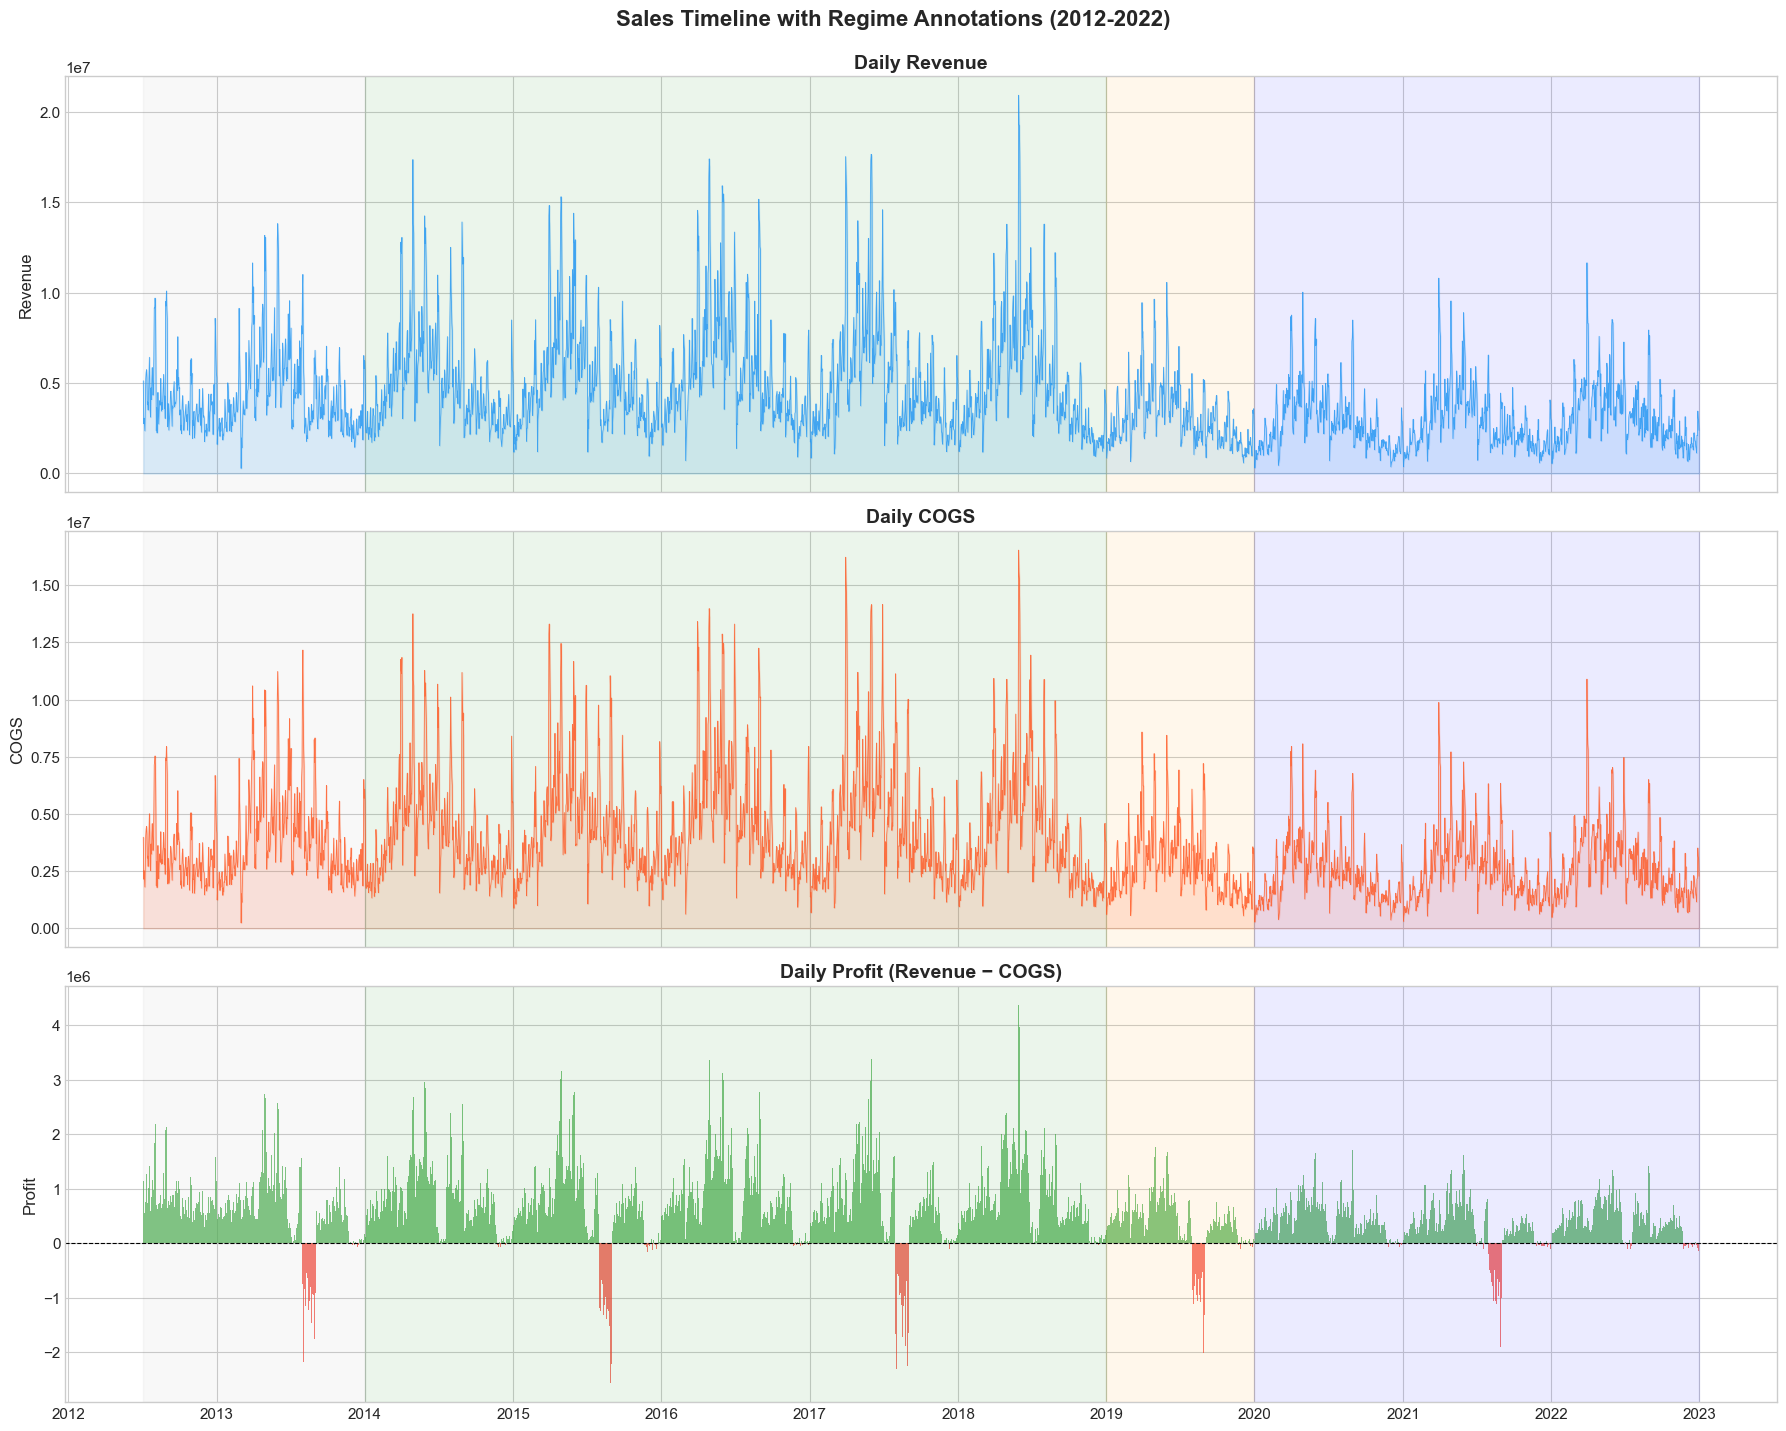

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

axes[0].plot(sales['Date'], sales['Revenue'], color='#2196F3', linewidth=0.6, alpha=0.8)
axes[0].fill_between(sales['Date'], sales['Revenue'], alpha=0.15, color='#2196F3')
axes[0].set_title('Daily Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue')

axes[1].plot(sales['Date'], sales['COGS'], color='#FF5722', linewidth=0.6, alpha=0.8)
axes[1].fill_between(sales['Date'], sales['COGS'], alpha=0.15, color='#FF5722')
axes[1].set_title('Daily COGS', fontweight='bold')
axes[1].set_ylabel('COGS')

profit = sales['Revenue'] - sales['COGS']
colors = np.where(profit >= 0, '#4CAF50', '#F44336')
axes[2].bar(sales['Date'], profit, color=colors, width=1, alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Daily Profit (Revenue − COGS)', fontweight='bold')
axes[2].set_ylabel('Profit')

for ax in axes:
    ax.axvspan(pd.Timestamp('2012-07-04'), pd.Timestamp('2013-12-31'), alpha=0.05, color='gray', label='2012-13: Noisy')
    ax.axvspan(pd.Timestamp('2014-01-01'), pd.Timestamp('2018-12-31'), alpha=0.08, color='green', label='2014-18: Peak')
    ax.axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2019-12-31'), alpha=0.08, color='orange', label='2019: Jump')
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2022-12-31'), alpha=0.08, color='blue', label='2020-22: New regime')
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.suptitle('Sales Timeline with Regime Annotations (2012-2022)', y=1.02, fontsize=16, fontweight='bold')
plt.show()

### 2.2 Cấu trúc mùa vụ: Shape có bền vững không?

**Câu hỏi:** Shape mùa vụ có thay đổi theo regime, hay vẫn giữ ổn định?

Nếu shape ổn định -> chiến lược **"học shape ở vùng sạch rồi rescale"** là khả thi.  
Nếu shape cũng biến đổi -> chiến lược đó sụp đổ.

**Kết quả kỳ vọng:** Tất cả các đường cong có cùng dáng: sụt Q1 (Tết), bật lên Q2, plateau giữa năm, bung cao Q4. Sự khác biệt giữa các năm **chủ yếu nằm ở level** (mức trung bình), còn shape gần như bất biến. -> **"Mùa vụ bền vững, level thay đổi"** - nền tảng cho toàn bộ pipeline.

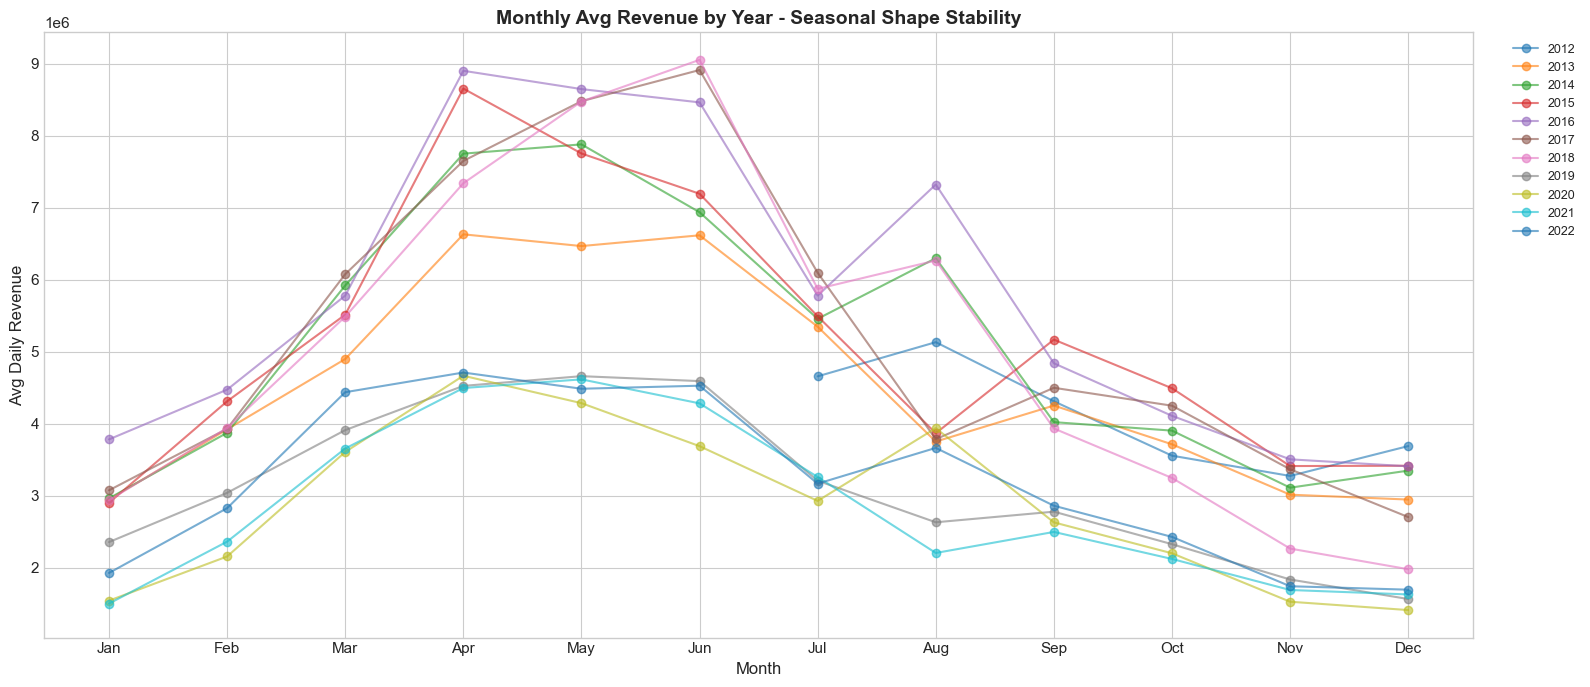

Key insight: Shape STABLE across years (dip Q1/Tet, peak Q2+Q4), only LEVEL changes.
    Strategy: learn shape from clean era (2014-18), calibrate level separately.


In [23]:
sales_tmp = sales.copy()
sales_tmp['year'] = sales_tmp['Date'].dt.year
sales_tmp['month'] = sales_tmp['Date'].dt.month

fig, ax = plt.subplots(figsize=(16, 7))
for year in sorted(sales_tmp['year'].unique()):
    subset = sales_tmp[sales_tmp['year'] == year]
    monthly_avg = subset.groupby('month')['Revenue'].mean()
    ax.plot(monthly_avg.index, monthly_avg.values, marker='o', alpha=0.6, label=str(year))

ax.set_title('Monthly Avg Revenue by Year - Seasonal Shape Stability', fontweight='bold', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Avg Daily Revenue')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print('Key insight: Shape STABLE across years (dip Q1/Tet, peak Q2+Q4), only LEVEL changes.')
print('    Strategy: learn shape from clean era (2014-18), calibrate level separately.')

### 2.3 Pattern lịch biểu: Day-of-Week & Day-of-Month

**Câu hỏi:** Doanh thu có phụ thuộc vào thứ trong tuần hay vị trí trong tháng không?

Hai pattern nhỏ nhưng có ý nghĩa cho mô hình, đặc biệt LightGBM (mô hình cây bắt được split trên các ngưỡng này).

**Kỳ vọng phát hiện:**
- **Weekend ngược** - weekday cao hơn weekend (khác retail B2C thông thường) -> feature `is_weekend`
- **EOM spike** - ngày 28-31 cuối tháng cao gấp đôi ngày giữa tháng (đỉnh ~7.5M vào ngày 31) -> features `is_last1..3`, `days_to_eom`
- **SOM spike** - ngày 1-3 cũng cao (~5-6M) -> features `is_first1..3`, `days_from_som`

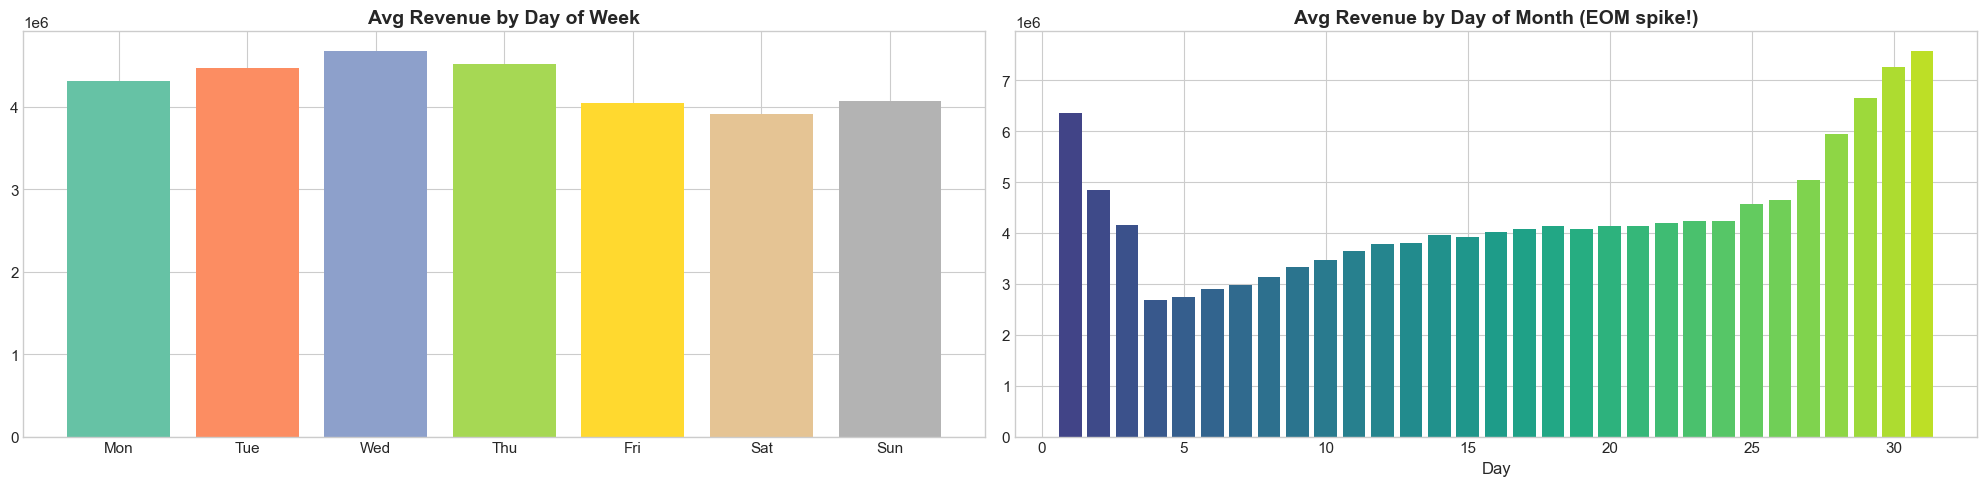

In [24]:
sales_tmp['dayofweek'] = sales_tmp['Date'].dt.dayofweek
sales_tmp['day'] = sales_tmp['Date'].dt.day

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

dow_avg = sales_tmp.groupby('dayofweek')['Revenue'].mean()
axes[0].bar(dow_avg.index, dow_avg.values, color=plt.cm.Set2(np.linspace(0, 1, 7)))
axes[0].set_title('Avg Revenue by Day of Week', fontweight='bold')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

dom_avg = sales_tmp.groupby('day')['Revenue'].mean()
axes[1].bar(dom_avg.index, dom_avg.values, color=plt.cm.viridis(np.linspace(0.2, 0.9, 31)))
axes[1].set_title('Avg Revenue by Day of Month (EOM spike!)', fontweight='bold')
axes[1].set_xlabel('Day')

plt.tight_layout()
plt.show()

### 2.4 Chu kỳ năm chẵn/lẻ & Margin Q3 zig-zag

**Câu hỏi:** Hai nhóm năm chẵn/lẻ có thực sự khác nhau trong dữ liệu không?

Bảng `promotions.csv` cho thấy có 2 chiến dịch **chỉ xuất hiện ở năm lẻ**: `Urban Blowout` (cuối tháng 7) và `Rural Special` (cuối tháng 1). Điều này tạo ra 2 pattern quan trọng:

1. **Tháng 8 năm chẵn** có doanh thu cao đột biến (~5.4M) vs năm lẻ (~3.3M) - chênh gần 1.6×
2. **Q3 có margin zig-zag** theo chu kỳ chẵn/lẻ:
   - Năm lẻ (2013, 2015, 2017, 2019, 2021): margin Q3 vọt lên ~1.02-1.07 (COGS > Revenue - **bán lỗ**)
   - Năm chẵn: margin Q3 bình thường ~0.85

-> Trực tiếp dẫn đến: **(a)** feature `is_odd_year`, **(b)** mô hình **Q-Specialist** cho từng quý

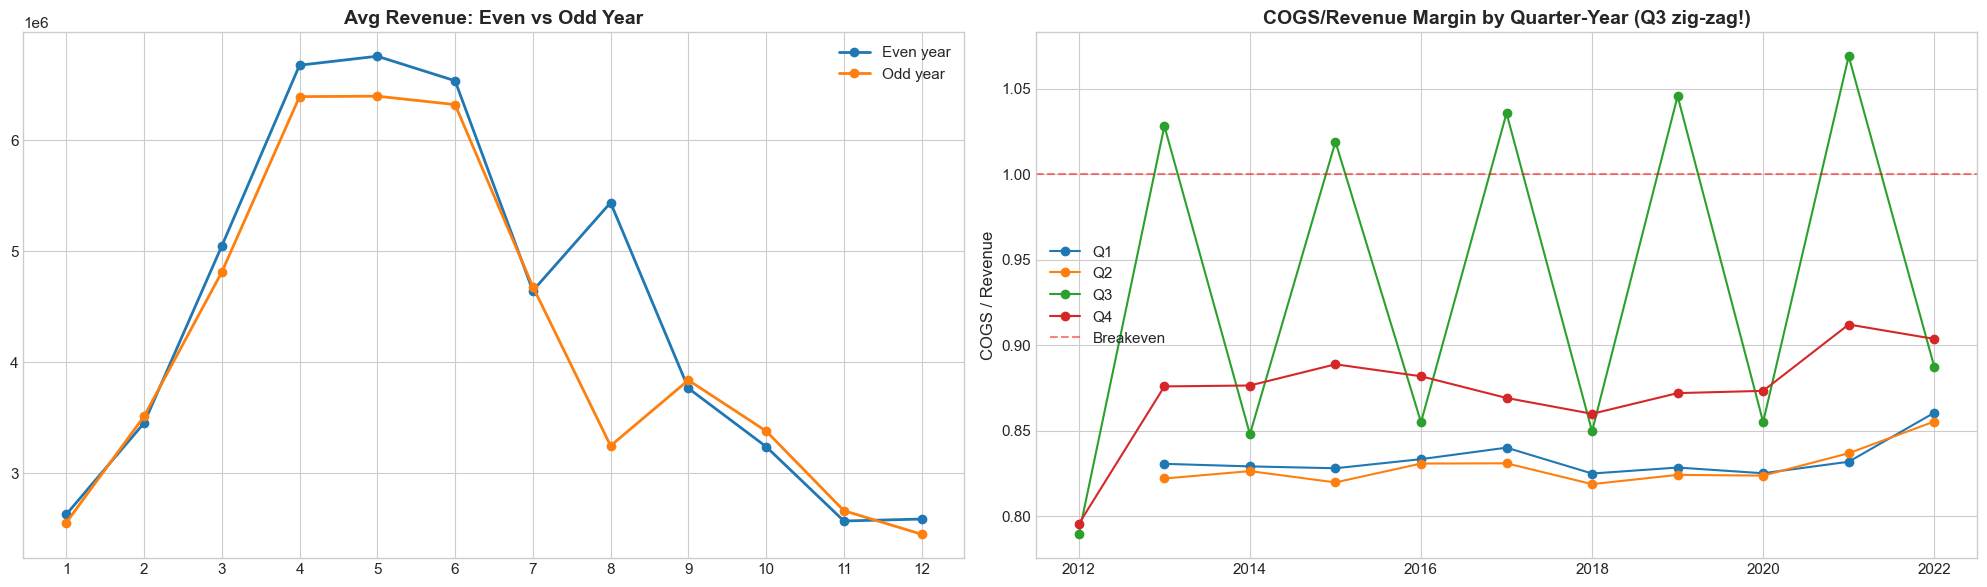

In [25]:
sales_tmp['quarter'] = sales_tmp['Date'].dt.quarter
sales_tmp['is_odd_year'] = sales_tmp['year'] % 2

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for label, group in sales_tmp.groupby('is_odd_year'):
    monthly = group.groupby('month')['Revenue'].mean()
    axes[0].plot(monthly.index, monthly.values, marker='o', linewidth=2,
                 label='Odd year' if label else 'Even year')
axes[0].set_title('Avg Revenue: Even vs Odd Year', fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].legend()

quarterly = sales_tmp.groupby(['year', 'quarter']).agg({'Revenue': 'sum', 'COGS': 'sum'}).reset_index()
quarterly['margin'] = quarterly['COGS'] / quarterly['Revenue']

for q in [1, 2, 3, 4]:
    q_data = quarterly[quarterly['quarter'] == q]
    axes[1].plot(q_data['year'], q_data['margin'], marker='o', linewidth=1.5, label=f'Q{q}')
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Breakeven')
axes[1].set_title('COGS/Revenue Margin by Quarter-Year (Q3 zig-zag!)', fontweight='bold')
axes[1].legend()
axes[1].set_ylabel('COGS / Revenue')

plt.tight_layout()
plt.show()

### 2.5 Phân phối Revenue theo Era & Scatter Revenue-COGS

**Câu hỏi 1:** Phân phối Revenue có tách biệt giữa các era không?  
**Câu hỏi 2:** Mối liên hệ Revenue-COGS có đặc điểm gì?

**Phát hiện chính:**
- **3 phân phối gần như không chồng lấp** -> nếu mọi mẫu có cùng trọng số, mô hình sẽ thoả hiệp ở mức trung bình không thuộc phân phối nào -> nguồn gốc "calibration bias" -> cần **tầng calibration tách rời**
- **COGS ≈ 0.88 × Revenue** (tuyến tính) - nhưng Q3 năm lẻ vi phạm giả định margin ổn định -> dự báo COGS **độc lập** (không qua tỉ số)

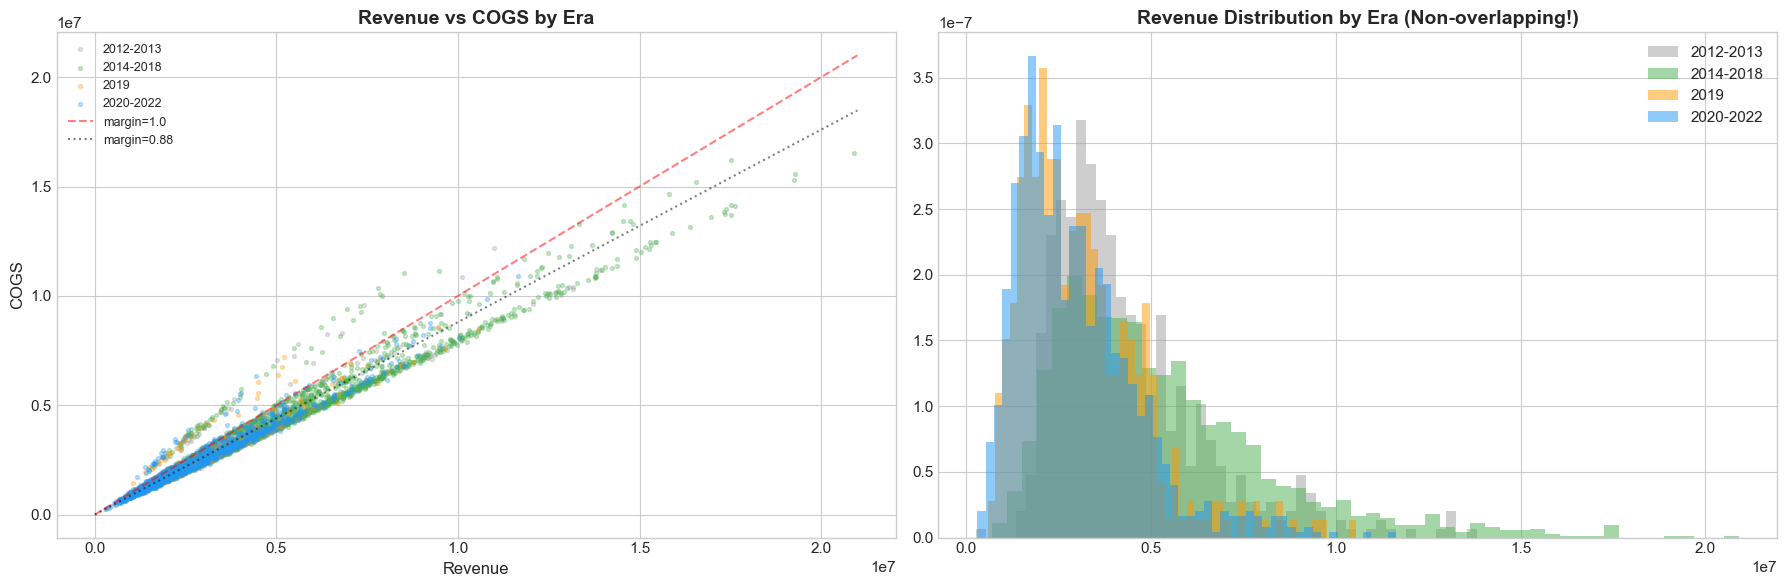

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

era_colors = {'2012-2013': '#9E9E9E', '2014-2018': '#4CAF50', '2019': '#FF9800', '2020-2022': '#2196F3'}
def get_era(y):
    if y <= 2013: return '2012-2013'
    elif y <= 2018: return '2014-2018'
    elif y == 2019: return '2019'
    else: return '2020-2022'

sales_tmp['era'] = sales_tmp['year'].map(get_era)
for era, color in era_colors.items():
    mask = sales_tmp['era'] == era
    axes[0].scatter(sales_tmp.loc[mask, 'Revenue'], sales_tmp.loc[mask, 'COGS'],
                    alpha=0.3, s=8, c=color, label=era)
axes[0].plot([0, 2.1e7], [0, 2.1e7], 'r--', alpha=0.5, label='margin=1.0')
axes[0].plot([0, 2.1e7], [0, 2.1e7*0.88], 'k:', alpha=0.5, label='margin=0.88')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('COGS')
axes[0].set_title('Revenue vs COGS by Era', fontweight='bold')
axes[0].legend(fontsize=9)

for era, color in era_colors.items():
    mask = sales_tmp['era'] == era
    axes[1].hist(sales_tmp.loc[mask, 'Revenue'], bins=50, alpha=0.5, color=color, label=era, density=True)
axes[1].set_title('Revenue Distribution by Era (Non-overlapping!)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.6 Year × Month Revenue Heatmap

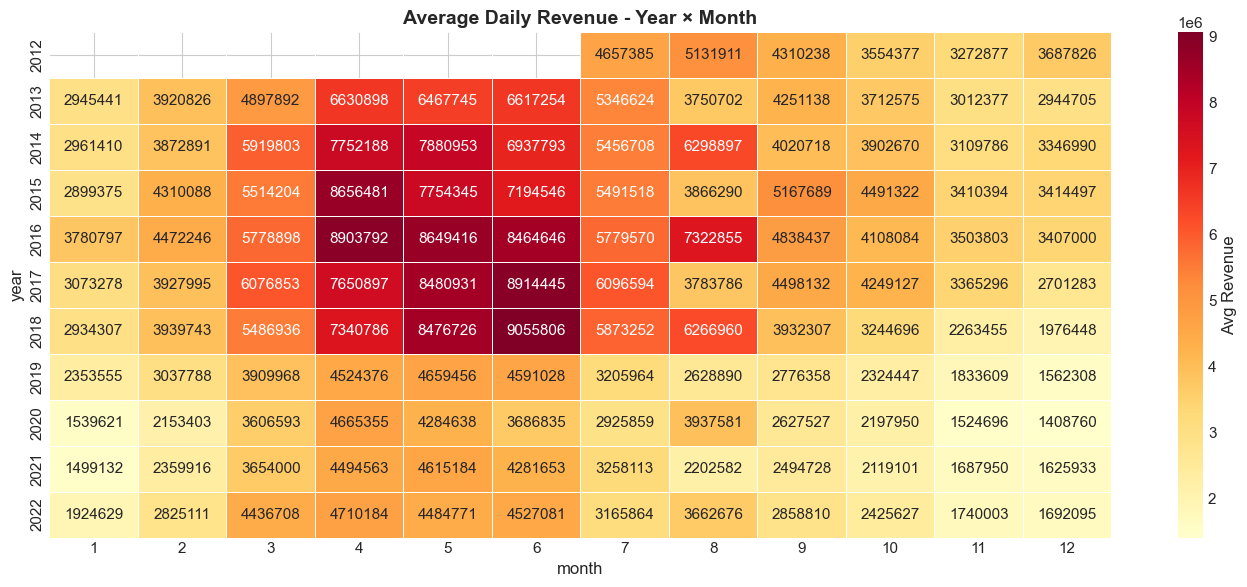

In [27]:
pivot_rev = sales_tmp.pivot_table(index='year', columns='month', values='Revenue', aggfunc='mean')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_rev, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Revenue'})
ax.set_title('Average Daily Revenue - Year × Month', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 2.7 Tóm tắt EDA cho dự đoán -> Quyết định thiết kế

Sáu phát hiện trên kết nối trực tiếp từ quan sát dữ liệu đến quyết định thiết kế pipeline:

| # | Quan sát | Feature / Cơ chế tạo ra | Vai trò trong pipeline |
|---|---|---|---|
| 1 | **Ba regime riêng biệt** (2012-13, 2014-18, 2019+) | `regime_pre2019`, `regime_2019`, `regime_post2019` | Sample weight (era-based) + calibration tầng 3 |
| 2 | **Mùa vụ ổn định** qua các năm (shape bất biến) | Fourier annual k=1..5, weekly k=1..2, monthly k=1..2 | Ridge học periodic patterns qua tổng trọng số sin/cos |
| 3 | **Hiệu ứng Tết** (sụt sâu ±3 ngày, hồi phục sau 7 ngày) | `tet_days_diff`, `tet_in_7`, `tet_in_14`, `tet_before_7`, `tet_after_7`, `tet_on` | Mã hoá chính xác vị trí Tết bất kể ngày dương lịch |
| 4 | **EOM spike** (ngày 28-31 cao nhất) & SOM spike (ngày 1-3) | `is_last1..3`, `days_to_eom`, `is_first1..3`, `days_from_som` | LightGBM bắt được split trên các ngưỡng này |
| 5 | **Năm chẵn cao đột biến tháng 8** | `is_odd_year` | Binary flag cho phép model chuyển đổi pattern chẵn/lẻ |
| 6 | **Q3 zig-zag** chẵn/lẻ (urban_blowout) | - | Q-specialist models + `is_odd_year` |

---
<a id='3'></a>
## 3. Feature Engineering (Calendar-Only)

### Nguyên tắc cốt lõi: Không dùng feature lag

> **Khi horizon dài 548 ngày, feature lag ($y_{t-1}$, $y_{t-7}$, $y_{t-365}$) không còn truy cập được**: ta không biết Revenue hôm qua của 548 ngày tương lai. Phương án duy nhất ổn định là dùng **feature calendar thuần** - mọi đặc trưng đều tính được từ ngày tháng, không phụ thuộc vào lịch sử.

Với mọi ngày $t$, trích ra **3 nhóm thông tin**:

1. **Vị trí trong lịch:** năm, tháng, ngày, thứ, ngày trong năm, quý, edge-of-month
2. **Fourier features:** sin/cos của day-of-year (k=1..5), day-of-week (k=1..2), day-of-month (k=1..2) - đóng vai trò đặc biệt quan trọng cho Ridge, giúp mô hình tuyến tính học được pattern lặp định kỳ
3. **Quan hệ với mốc lễ & promo:** khoảng cách tới Tết, Black Friday, 10 ngày lễ cố định VN, 6 cửa sổ promo (4 thường niên + 2 năm lẻ) với thông tin since/until/discount

### 3.1 Định nghĩa Tết âm lịch & lịch Promo

In [28]:
TET_DATES = {
    2013: '2013-02-10', 2014: '2014-01-31', 2015: '2015-02-19',
    2016: '2016-02-08', 2017: '2017-01-28', 2018: '2018-02-16',
    2019: '2019-02-05', 2020: '2020-01-25', 2021: '2021-02-12',
    2022: '2022-02-01', 2023: '2023-01-22', 2024: '2024-02-10',
}

PROMO_SCHEDULE = [
    ('spring_sale',    3, 18, 30, 12, True),
    ('mid_year',       6, 23, 29, 18, True),
    ('fall_launch',    8, 30, 32, 10, True),
    ('year_end',      11, 18, 45, 20, True),
    ('urban_blowout',  7, 30, 33, None, 'odd'),
    ('rural_special',  1, 30, 30, 15,   'odd'),
]

VN_FIXED_HOLIDAYS = [
    (1,  1,  'new_year'),    (3,  8,  'womens_day'),
    (4,  30, 'reunification'), (5,  1,  'labor_day'),
    (9,  2,  'national_day'), (10, 20, 'vn_womens_day'),
    (11, 11, 'dd_1111'),     (12, 12, 'dd_1212'),
    (12, 24, 'christmas_eve'), (12, 25, 'christmas'),
]

print(f'Tet dates: {len(TET_DATES)} years | Promo campaigns: {len(PROMO_SCHEDULE)} | Fixed holidays: {len(VN_FIXED_HOLIDAYS)}')

Tet dates: 12 years | Promo campaigns: 6 | Fixed holidays: 10


### 3.2 Hàm `build_features()` - Calendar-Only Featurization

Hàm này là trái tim của pipeline. Nó nhận vào một DatetimeIndex và trả về DataFrame với **150+ features** hoàn toàn từ Date - **không phụ thuộc vào giá trị lịch sử** nào.

Gồm 9 nhóm features:
- **(a)** Calendar basics: year, month, day, dow, doy, quarter, is_weekend, days_to_eom, days_from_som, dim
- **(b)** Edge-of-month: is_last1/2/3, is_first1/2/3
- **(c)** Trend & regime: t_days, t_years, regime_pre2019/2019/post2019
- **(d)** Fourier: annual k=1..5, weekly k=1..2, monthly k=1..2 (tổng 18 features)
- **(e)** VN holidays: 10 binary flags
- **(f)** Tet: tet_days_diff, tet_in_7/14, tet_before_7/after_7, tet_on
- **(g)** Black Friday: 1 binary flag
- **(h)** Promo windows: 6 campaigns × 4 features (in_prom, since, until, disc) = 24 features
- **(i)** is_odd_year: binary flag

In [29]:
def build_features(dates: pd.DatetimeIndex) -> pd.DataFrame:
    df = pd.DataFrame({'Date': dates})
    d = df['Date']

    df['year']  = d.dt.year
    df['month'] = d.dt.month
    df['day']   = d.dt.day
    df['dow']   = d.dt.dayofweek
    df['doy']   = d.dt.dayofyear
    df['quarter'] = d.dt.quarter
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['days_to_eom']   = d.dt.days_in_month - df['day']
    df['days_from_som'] = df['day'] - 1
    df['dim'] = d.dt.days_in_month

    for k in [1, 2, 3]:
        df[f'is_last{k}']  = (df['days_to_eom'] <= k - 1).astype(int)
        df[f'is_first{k}'] = (df['days_from_som'] <= k - 1).astype(int)

    df['t_days'] = (d - pd.Timestamp('2020-01-01')).dt.days
    df['t_years'] = df['t_days'] / 365.25
    df['regime_pre2019']  = (df['year'] <= 2018).astype(int)
    df['regime_2019']     = (df['year'] == 2019).astype(int)
    df['regime_post2019'] = (df['year'] >= 2020).astype(int)

    TAU = 2 * np.pi
    for k in (1, 2, 3, 4, 5):
        df[f'sin_y{k}'] = np.sin(TAU * k * df['doy'] / 365.25)
        df[f'cos_y{k}'] = np.cos(TAU * k * df['doy'] / 365.25)
    for k in (1, 2):
        df[f'sin_w{k}'] = np.sin(TAU * k * df['dow'] / 7.0)
        df[f'cos_w{k}'] = np.cos(TAU * k * df['dow'] / 7.0)
    for k in (1, 2):
        df[f'sin_m{k}'] = np.sin(TAU * k * (df['day'] - 1) / df['dim'])
        df[f'cos_m{k}'] = np.cos(TAU * k * (df['day'] - 1) / df['dim'])

    for (m, dd_, name) in VN_FIXED_HOLIDAYS:
        df[f'hol_{name}'] = ((df['month'] == m) & (df['day'] == dd_)).astype(int)

    tet_lut = {y: pd.Timestamp(v) for y, v in TET_DATES.items()}
    def nearest_tet_diff(dd):
        cands = [tet_lut.get(dd.year), tet_lut.get(dd.year - 1), tet_lut.get(dd.year + 1)]
        cands = [c for c in cands if c is not None]
        valid = [(dd - c).days for c in cands if abs((dd - c).days) <= 45]
        return min(valid, key=abs) if valid else 999
    diffs = np.array([nearest_tet_diff(dd) for dd in d])
    df['tet_days_diff'] = diffs
    df['tet_in_7']      = (np.abs(diffs) <= 7).astype(int)
    df['tet_in_14']     = (np.abs(diffs) <= 14).astype(int)
    df['tet_before_7']  = ((diffs >= -7) & (diffs < 0)).astype(int)
    df['tet_after_7']   = ((diffs > 0) & (diffs <= 7)).astype(int)
    df['tet_on']        = (diffs == 0).astype(int)

    def is_black_friday(dd):
        if dd.month != 11: return 0
        last = pd.Timestamp(year=dd.year, month=11, day=30)
        last_fri = last - pd.Timedelta(days=(last.dayofweek - 4) % 7)
        return int(dd == last_fri)
    df['hol_black_friday'] = [is_black_friday(dd) for dd in d]

    yrs = sorted(set(df['year'].tolist()))
    for (name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        in_prom  = np.zeros(len(df), dtype=int)
        since    = np.full(len(df), -1.0)
        until    = np.full(len(df), -1.0)
        discount = np.zeros(len(df))
        for y in range(min(yrs) - 1, max(yrs) + 2):
            if recur == 'odd' and y % 2 == 0: continue
            try: start = pd.Timestamp(year=y, month=sm, day=sd)
            except ValueError: continue
            end = start + pd.Timedelta(days=dur)
            mask = (d >= start) & (d <= end)
            in_prom[mask] = 1
            since[mask] = (d[mask] - start).dt.days
            until[mask] = (end - d[mask]).dt.days
            discount[mask] = disc or 0
        df[f'promo_{name}']       = in_prom
        df[f'promo_{name}_since'] = since
        df[f'promo_{name}_until'] = until
        df[f'promo_{name}_disc']  = discount

    df['is_odd_year'] = (df['year'] % 2).astype(int)
    return df

test_features = build_features(pd.date_range('2023-01-01', '2023-01-10'))
print(f'Feature columns: {test_features.shape[1]}')
test_features.head()

Feature columns: 82


,Date,year,month,day,dow,doy,quarter,is_weekend,days_to_eom,days_from_som,...,promo_year_end_disc,promo_urban_blowout,promo_urban_blowout_since,promo_urban_blowout_until,promo_urban_blowout_disc,promo_rural_special,promo_rural_special_since,promo_rural_special_until,promo_rural_special_disc,is_odd_year
0,2023-01-01,2023,1,1,6,1,1,1,30,0,...,20.0,0,-1.0,-1.0,0.0,0,-1.0,-1.0,0.0,1
1,2023-01-02,2023,1,2,0,2,1,0,29,1,...,20.0,0,-1.0,-1.0,0.0,0,-1.0,-1.0,0.0,1
2,2023-01-03,2023,1,3,1,3,1,0,28,2,...,0.0,0,-1.0,-1.0,0.0,0,-1.0,-1.0,0.0,1
3,2023-01-04,2023,1,4,2,4,1,0,27,3,...,0.0,0,-1.0,-1.0,0.0,0,-1.0,-1.0,0.0,1
4,2023-01-05,2023,1,5,3,5,1,0,26,4,...,0.0,0,-1.0,-1.0,0.0,0,-1.0,-1.0,0.0,1


### 3.3 Xây dựng ma trận feature cho Training & Test

Nhờ calendar-only, ma trận test có thể tính sẵn **đầy đủ ngay từ đầu** - không phải tính lại trong lúc rolling.

In [30]:
feat_train = build_features(sales['Date'])
feat_train['Revenue'] = sales['Revenue'].values
feat_train['COGS'] = sales['COGS'].values

feat_test = build_features(submission_template['Date'])

FEATURE_COLS = [c for c in feat_train.columns if c not in ['Date', 'Revenue', 'COGS']]

print(f'Training features: {feat_train.shape} ({len(FEATURE_COLS)} features)')
print(f'Test features    : {feat_test.shape} ({len(FEATURE_COLS)} features)')
print(f'\n All features computable from Date alone - no lag dependency!')

Training features: (3833, 84) (81 features)
Test features    : (548, 82) (81 features)

 All features computable from Date alone - no lag dependency!


---
<a id='4'></a>
## 4. Validation Strategy (3 Temporal Folds)

Vì horizon test rất dài và phân phối khác biệt so với training, cần thiết kế fold validation cẩn thận. **3 fold** được thiết kế với 3 mục tiêu bổ sung nhau:

| Fold | Train | Validate | Mục tiêu |
|---|---|---|---|
| **A (primary)** | ≤ 2021-12 | 2022 | Phân phối gần nhất với test -> quyết định ablation chính |
| **B (stability)** | ≤ 2020-12 | 2021 | Kiểm tra cải tiến có ổn định qua năm |
| **C (horizon)** | ≤ 2021-06 | 2021-07 -> 2022-06 | Mô phỏng cửa sổ 12 tháng liên tục, gần horizon test nhất |

### 4.1 Era-based Sample Weights

Kỹ thuật cổ điển nhưng rất hiệu quả cho data có regime drift: **upweight vùng 2014-2018** (w=1.0) nơi model cần học pattern tốt nhất, **downweight phần còn lại** (w=0.01). Hiệu ứng: mô hình tập trung học **shape** từ vùng sạch, sau đó chỉ cần điều chỉnh **level** bằng calibration.

In [31]:
FOLDS = {
    'A': {'train_end': '2021-12-31', 'val_start': '2022-01-01', 'val_end': '2022-12-31'},
    'B': {'train_end': '2020-12-31', 'val_start': '2021-01-01', 'val_end': '2021-12-31'},
    'C': {'train_end': '2021-06-30', 'val_start': '2021-07-01', 'val_end': '2022-06-30'},
}

def get_fold(feat_df, fold_name):
    f = FOLDS[fold_name]
    train_mask = feat_df['Date'] <= f['train_end']
    val_mask   = (feat_df['Date'] >= f['val_start']) & (feat_df['Date'] <= f['val_end'])
    return feat_df[train_mask].copy(), feat_df[val_mask].copy()

def make_era_weights(years):
    w = np.full(len(years), 0.01)
    w[(years >= 2014) & (years <= 2018)] = 1.0
    return w

for name, spec in FOLDS.items():
    tr, va = get_fold(feat_train, name)
    print(f'Fold {name}: Train={len(tr):,} days, Val={len(va):,} days  ({spec["val_start"]} -> {spec["val_end"]})')

Fold A: Train=3,468 days, Val=365 days  (2022-01-01 -> 2022-12-31)
Fold B: Train=3,103 days, Val=365 days  (2021-01-01 -> 2021-12-31)
Fold C: Train=3,284 days, Val=365 days  (2021-07-01 -> 2022-06-30)


---
<a id='5'></a>
## 5. Model 1: Ridge Regression

### Vai trò trong ensemble

Ridge đại diện cho **mô hình tuyến tính tham số**. Nó học một hàm tuyến tính toàn cục trên không gian feature. Khi được cung cấp đủ Fourier features (sin/cos nhiều tần số), Ridge có thể tái hiện dạng mùa vụ theo kiểu **tổng trọng số sin/cos nhiều tần số**.

**Ưu điểm chính:** Ridge rất **ổn định** (low variance) - train lại nhiều lần cho ra weight rất gần nhau, ít bị nhiễu bởi outlier. Nó đóng vai trò **"anchor"** - thành phần khó bị lệch bất thường trong ensemble.

### Hai điểm kỹ thuật quan trọng

1. **Z-score normalization** trước khi fit - Ridge nhạy cảm với scale của features
2. **Train trên log(Revenue/COGS)** rồi `exp()` ngược - log-space ổn định hơn khi biên độ dao động lớn

In [32]:
def train_ridge(X_train, y_train, alpha=3.0):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0).replace(0, 1)
    Xs = (X_train - mu) / sigma
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(Xs, y_train)
    return model, (mu, sigma)

def predict_ridge(model, X_test, stats):
    mu, sigma = stats
    return model.predict((X_test - mu) / sigma)

tr_A, va_A = get_fold(feat_train, 'A')
X_tr = tr_A[FEATURE_COLS]
X_va = va_A[FEATURE_COLS]

y_tr_log_rev = np.log(tr_A['Revenue'].values)
ridge_rev, stats_rev = train_ridge(X_tr, y_tr_log_rev)
p_ridge_rev_val = np.exp(predict_ridge(ridge_rev, X_va, stats_rev))

y_tr_log_cogs = np.log(tr_A['COGS'].values)
ridge_cogs, stats_cogs = train_ridge(X_tr, y_tr_log_cogs)
p_ridge_cogs_val = np.exp(predict_ridge(ridge_cogs, X_va, stats_cogs))

mae_ridge_rev = mean_absolute_error(va_A['Revenue'], p_ridge_rev_val)
mae_ridge_cogs = mean_absolute_error(va_A['COGS'], p_ridge_cogs_val)
rmse_ridge_rev = np.sqrt(mean_squared_error(va_A['Revenue'], p_ridge_rev_val))
rmse_ridge_cogs = np.sqrt(mean_squared_error(va_A['COGS'], p_ridge_cogs_val))

print(f'Ridge Revenue (Fold A) - MAE: {mae_ridge_rev:,.0f}  RMSE: {rmse_ridge_rev:,.0f}')
print(f'Ridge COGS    (Fold A) - MAE: {mae_ridge_cogs:,.0f}  RMSE: {rmse_ridge_cogs:,.0f}')

Ridge Revenue (Fold A) - MAE: 712,634  RMSE: 1,009,898
Ridge COGS    (Fold A) - MAE: 653,334  RMSE: 919,755


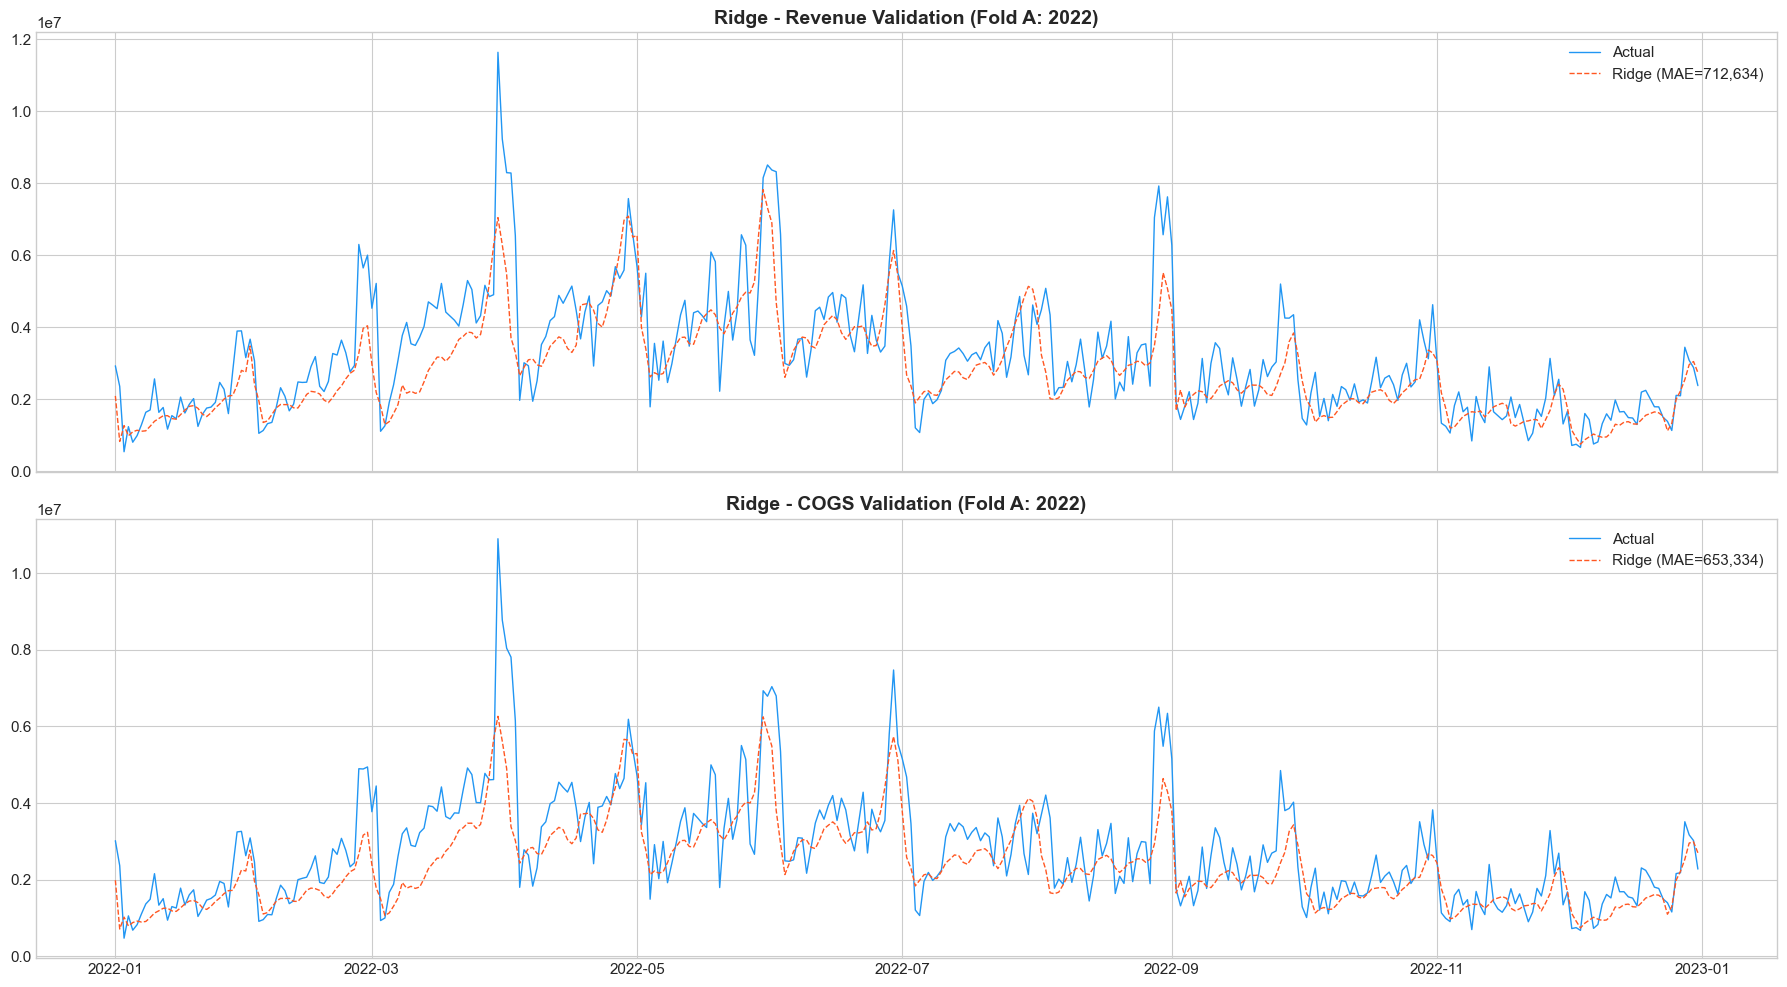

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
axes[0].plot(va_A['Date'].values, va_A['Revenue'].values, label='Actual', color='#2196F3', linewidth=1)
axes[0].plot(va_A['Date'].values, p_ridge_rev_val, label=f'Ridge (MAE={mae_ridge_rev:,.0f})', color='#FF5722', linewidth=1, linestyle='--')
axes[0].set_title('Ridge - Revenue Validation (Fold A: 2022)', fontweight='bold')
axes[0].legend()
axes[1].plot(va_A['Date'].values, va_A['COGS'].values, label='Actual', color='#2196F3', linewidth=1)
axes[1].plot(va_A['Date'].values, p_ridge_cogs_val, label=f'Ridge (MAE={mae_ridge_cogs:,.0f})', color='#FF5722', linewidth=1, linestyle='--')
axes[1].set_title('Ridge - COGS Validation (Fold A: 2022)', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

---
<a id='6'></a>
## 6. Model 2: LightGBM with Sample Weighting

### Vai trò trong ensemble

LightGBM đại diện cho **mô hình cây gradient boosting**. Khác với Ridge, LGB không giả định quan hệ tuyến tính mà học hàm dạng **bậc thang** (piecewise-constant) qua việc chia feature space. Ưu điểm lớn nhất là nắm được **tương tác giữa các feature** (ví dụ: "nếu là cuối tháng AND có promo thì tăng mạnh").

LGB mạnh nhất nhưng cũng **variance cao nhất** giữa các seed -> cần regularize bằng trọng số trong ensemble. Nó chiếm tỉ trọng **80%** trong Tầng 2 của ensemble.

### Huấn luyện 2 giai đoạn

1. **Giai đoạn 1:** Dùng 180 ngày cuối làm validation để xác định `best_iteration` (early stopping)
2. **Giai đoạn 2:** Huấn luyện lại trên **toàn bộ dữ liệu** với số vòng đã chọn

Cách này giúp model tận dụng được cả 180 ngày cuối trong khi tránh overfit.

### Hyperparameters

Cấu hình conservative: `learning_rate=0.03`, `num_leaves=63`, `min_data_in_leaf=30`, `lambda_l2=1.0` - tránh overfit cho horizon dài.

In [34]:
LGB_PARAMS = dict(
    objective='regression', metric='mae',
    learning_rate=0.03, num_leaves=63,
    min_data_in_leaf=30,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
    lambda_l2=1.0, seed=42, verbosity=-1,
)

def train_lgb_2phase(X_train, y_train_log, weights, holdout_days=180,
                      num_boost_round=5000, early_stop=300):
    n = len(X_train)
    split = n - holdout_days

    ds_fit = lgb.Dataset(X_train[:split], y_train_log[:split], weight=weights[:split])
    ds_es  = lgb.Dataset(X_train[split:], y_train_log[split:])

    booster_es = lgb.train(
        LGB_PARAMS, ds_fit, num_boost_round=num_boost_round,
        valid_sets=[ds_es],
        callbacks=[lgb.early_stopping(early_stop, verbose=False), lgb.log_evaluation(0)])
    best_iter = booster_es.best_iteration
    print(f'  Phase 1: best_iteration = {best_iter}')

    ds_full = lgb.Dataset(X_train, y_train_log, weight=weights)
    booster_final = lgb.train(LGB_PARAMS, ds_full, num_boost_round=best_iter)
    return booster_final

In [35]:
tr_A, va_A = get_fold(feat_train, 'A')
X_tr_A = tr_A[FEATURE_COLS].values
X_va_A = va_A[FEATURE_COLS].values
w_tr_A = make_era_weights(tr_A['year'].values)

print('Training LGB for Revenue...')
y_tr_log_rev = np.log(tr_A['Revenue'].values)
lgb_rev_A = train_lgb_2phase(X_tr_A, y_tr_log_rev, w_tr_A)
p_lgb_rev_val = np.exp(lgb_rev_A.predict(X_va_A))

print('Training LGB for COGS...')
y_tr_log_cogs = np.log(tr_A['COGS'].values)
lgb_cogs_A = train_lgb_2phase(X_tr_A, y_tr_log_cogs, w_tr_A)
p_lgb_cogs_val = np.exp(lgb_cogs_A.predict(X_va_A))

mae_lgb_rev = mean_absolute_error(va_A['Revenue'], p_lgb_rev_val)
mae_lgb_cogs = mean_absolute_error(va_A['COGS'], p_lgb_cogs_val)
rmse_lgb_rev = np.sqrt(mean_squared_error(va_A['Revenue'], p_lgb_rev_val))
rmse_lgb_cogs = np.sqrt(mean_squared_error(va_A['COGS'], p_lgb_cogs_val))

print(f'\nLGB Revenue (Fold A) - MAE: {mae_lgb_rev:,.0f}  RMSE: {rmse_lgb_rev:,.0f}')
print(f'LGB COGS    (Fold A) - MAE: {mae_lgb_cogs:,.0f}  RMSE: {rmse_lgb_cogs:,.0f}')

Training LGB for Revenue...
  Phase 1: best_iteration = 385
Training LGB for COGS...
  Phase 1: best_iteration = 268

LGB Revenue (Fold A) - MAE: 568,480  RMSE: 778,989
LGB COGS    (Fold A) - MAE: 497,792  RMSE: 668,511


### 6.3 Feature Importance

Phân tích top features giúp xác nhận rằng các feature được thiết kế từ EDA thực sự có ảnh hưởng trong mô hình.

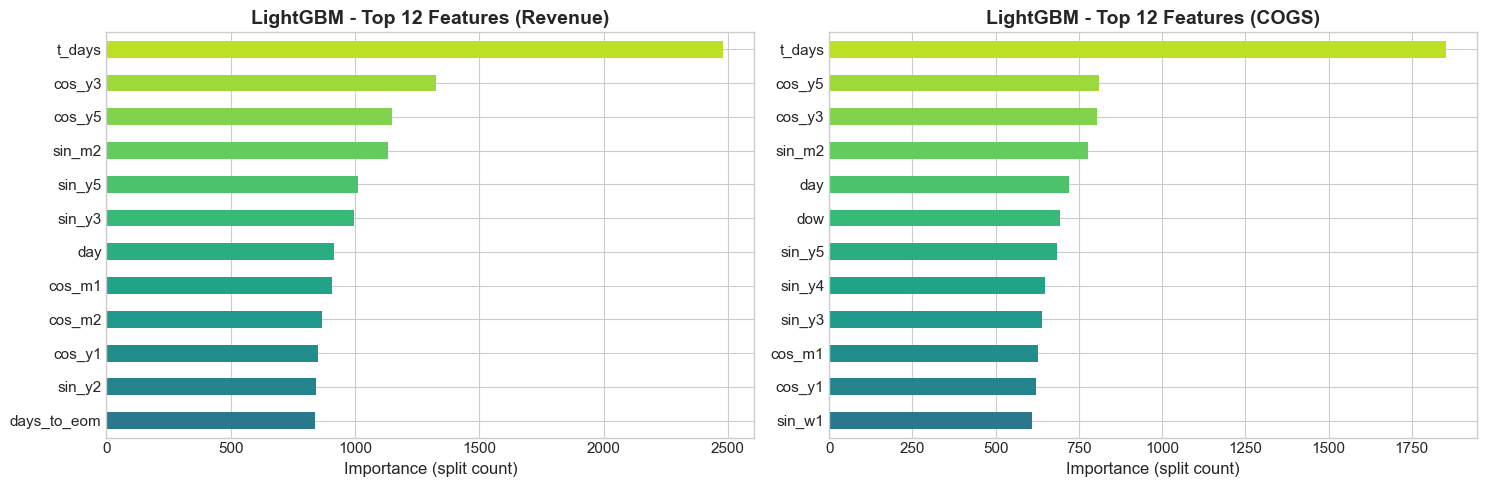

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, (model, name) in enumerate([(lgb_rev_A, 'Revenue'), (lgb_cogs_A, 'COGS')]):
    importance = pd.Series(model.feature_importance(), index=FEATURE_COLS).sort_values(ascending=True).tail(12)
    importance.plot(kind='barh', ax=axes[i], color=plt.cm.viridis(np.linspace(0.4, 0.9, 12)))
    axes[i].set_title(f'LightGBM - Top 12 Features ({name})', fontweight='bold')
    axes[i].set_xlabel('Importance (split count)')
plt.tight_layout()
plt.show()

---
<a id='7'></a>
## 7. Model 3: Prophet

### Vai trò trong ensemble

Prophet đại diện cho **mô hình phân rã có cấu trúc** (decomposition-based). Nó chia chuỗi thời gian thành 3 thành phần độc lập:
- **Trend** - piecewise linear có changepoint
- **Seasonality** - Fourier đa tần số
- **Holidays/Regressors** - promo windows

Vì cấu trúc được định trước, Prophet rất mạnh ở việc **extrapolate seasonal component cho horizon dài** - chính xác nhu cầu của bài toán 18 tháng.

### Lưu ý: `post_regime_only=True`

Prophet **chỉ train trên 2020-2022** (post-regime). Lý do: component trend của Prophet xử lý kém với jump lớn (bước nhảy 2019-2020) - khi train trên toàn bộ lịch sử, trend đoạn cuối bị bóp méo.

In [37]:
def build_promo_regressors(dates):
    df = pd.DataFrame({'ds': dates})
    d = df['ds']
    yrs = sorted(set(d.dt.year.tolist()))
    for (name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        in_prom = np.zeros(len(df), dtype=int)
        for y in range(min(yrs) - 1, max(yrs) + 2):
            if recur == 'odd' and y % 2 == 0: continue
            try: start = pd.Timestamp(year=y, month=sm, day=sd)
            except ValueError: continue
            end = start + pd.Timedelta(days=dur)
            mask = (d >= start) & (d <= end)
            in_prom[mask] = 1
        df[f'promo_{name}'] = in_prom
    return df

def fit_prophet(train_df, post_regime_only=True):
    if post_regime_only:
        train_df = train_df[train_df['ds'] >= '2020-01-01'].copy()
    m = Prophet(
        yearly_seasonality=True, weekly_seasonality=True,
        daily_seasonality=False, seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05)
    promo_cols = [c for c in train_df.columns if c.startswith('promo_')]
    for col in promo_cols:
        m.add_regressor(col)
    m.fit(train_df)
    return m

In [38]:
tr_A_dates = tr_A['Date'].values
promo_train = build_promo_regressors(pd.Series(tr_A_dates))
promo_cols = [c for c in promo_train.columns if c.startswith('promo_')]

print('Training Prophet for Revenue...')
tdf_rev = pd.DataFrame({'ds': tr_A_dates, 'y': np.log(tr_A['Revenue'].values)})
for col in promo_cols: tdf_rev[col] = promo_train[col].values
prophet_rev = fit_prophet(tdf_rev, post_regime_only=True)

print('Training Prophet for COGS...')
tdf_cogs = pd.DataFrame({'ds': tr_A_dates, 'y': np.log(tr_A['COGS'].values)})
for col in promo_cols: tdf_cogs[col] = promo_train[col].values
prophet_cogs = fit_prophet(tdf_cogs, post_regime_only=True)

promo_val = build_promo_regressors(pd.Series(va_A['Date'].values))
vdf = pd.DataFrame({'ds': va_A['Date'].values})
for col in promo_cols: vdf[col] = promo_val[col].values

p_prophet_rev_val = np.exp(prophet_rev.predict(vdf)['yhat'].values)
p_prophet_cogs_val = np.exp(prophet_cogs.predict(vdf)['yhat'].values)

mae_prophet_rev = mean_absolute_error(va_A['Revenue'], p_prophet_rev_val)
mae_prophet_cogs = mean_absolute_error(va_A['COGS'], p_prophet_cogs_val)
rmse_prophet_rev = np.sqrt(mean_squared_error(va_A['Revenue'], p_prophet_rev_val))
rmse_prophet_cogs = np.sqrt(mean_squared_error(va_A['COGS'], p_prophet_cogs_val))

print(f'Prophet Revenue (Fold A) - MAE: {mae_prophet_rev:,.0f}  RMSE: {rmse_prophet_rev:,.0f}')
print(f'Prophet COGS    (Fold A) - MAE: {mae_prophet_cogs:,.0f}  RMSE: {rmse_prophet_cogs:,.0f}')

Training Prophet for Revenue...


13:57:23 - cmdstanpy - INFO - Chain [1] start processing
13:57:24 - cmdstanpy - INFO - Chain [1] done processing
13:57:24 - cmdstanpy - INFO - Chain [1] start processing
13:57:24 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet for COGS...
Prophet Revenue (Fold A) - MAE: 991,020  RMSE: 1,340,828
Prophet COGS    (Fold A) - MAE: 896,430  RMSE: 1,204,284


---
<a id='8'></a>
## 8. Q-Specialist Models

### Bối cảnh

Quan sát từ EDA (Hình 8) cho thấy các quý có mức biến động rất khác nhau - đặc biệt **Q3 dao động zig-zag** theo chu kỳ chẵn/lẻ (COGS > Revenue ở Q3 năm lẻ). Một mô hình chung sẽ bị "trung bình hoá" và không bắt được pattern riêng của mỗi quý.

### Kiến trúc Q-Specialist

4 specialist hoàn toàn **giống M2** (cùng LightGBM, cùng features, cùng hyperparameters). Khác biệt duy nhất nằm ở **sample weight**: mỗi specialist có quý "trọng điểm" được nhân hệ số `Q-boost = 2.0`.

| Specialist | Quý trọng điểm | Pattern tập trung học |
|---|---|---|
| Spec_Q1 | Tháng 1-3 | Hiệu ứng Tết, sụt đầu năm |
| Spec_Q2 | Tháng 4-6 | Mid-year sale, đỉnh giữa năm |
| Spec_Q3 | Tháng 7-9 | **Margin biến động nhất**, urban_blowout |
| Spec_Q4 | Tháng 10-12 | Black Friday, 11.11, 12.12, Noel |

### Vì sao không train chỉ trên quý đích?

1. **Mất ngữ cảnh xuyên quý** - feature trend, regime, promo mang ý nghĩa toàn năm
2. **Giảm kích thước training xuống 1/4** (~450 ngày hiệu dụng -> dễ overfit)

`Q-boost = 2.0` là compromise: vẫn train trên toàn bộ dữ liệu để giữ ngữ cảnh, nhưng **nghiêng loss về phía quý đích**.

### Prediction: Ghép theo quý - KHÔNG trung bình

Với mỗi ngày test, chọn specialist thuộc **đúng quý** của ngày đó (ví dụ: 15/02 Q1 -> `spec[1]`, 20/08 Q3 -> `spec[3]`).

In [39]:
QBOOST = 3.0

def train_q_specialist(X_train, y_train_log, years, quarters, target_q, holdout_days=180):
    w = make_era_weights(years)
    w[quarters == target_q] *= QBOOST
    return train_lgb_2phase(X_train, y_train_log, w, holdout_days=holdout_days)

Q_train = tr_A['quarter'].values
years_tr = tr_A['year'].values
y_tr_log_rev = np.log(tr_A['Revenue'].values)
y_tr_log_cogs = np.log(tr_A['COGS'].values)

spec_rev_models = {}
spec_cogs_models = {}

for q in [1, 2, 3, 4]:
    print(f'\n--- Q{q} Specialist ---')
    print(f'  Revenue:')
    spec_rev_models[q] = train_q_specialist(X_tr_A, y_tr_log_rev, years_tr, Q_train, q)
    print(f'  COGS:')
    spec_cogs_models[q] = train_q_specialist(X_tr_A, y_tr_log_cogs, years_tr, Q_train, q)

print('\nAll 8 Q-specialists trained (4 quarters × 2 targets)')


--- Q1 Specialist ---
  Revenue:
  Phase 1: best_iteration = 248
  COGS:
  Phase 1: best_iteration = 220

--- Q2 Specialist ---
  Revenue:
  Phase 1: best_iteration = 344
  COGS:
  Phase 1: best_iteration = 360

--- Q3 Specialist ---
  Revenue:
  Phase 1: best_iteration = 382
  COGS:
  Phase 1: best_iteration = 345

--- Q4 Specialist ---
  Revenue:
  Phase 1: best_iteration = 365
  COGS:
  Phase 1: best_iteration = 521

All 8 Q-specialists trained (4 quarters × 2 targets)


In [40]:
Q_val = va_A['quarter'].values
spec_rev_preds = {q: np.exp(spec_rev_models[q].predict(X_va_A)) for q in [1,2,3,4]}
spec_cogs_preds = {q: np.exp(spec_cogs_models[q].predict(X_va_A)) for q in [1,2,3,4]}

p_spec_rev_val = np.zeros(len(va_A))
p_spec_cogs_val = np.zeros(len(va_A))
for q in [1, 2, 3, 4]:
    mask = Q_val == q
    p_spec_rev_val[mask] = spec_rev_preds[q][mask]
    p_spec_cogs_val[mask] = spec_cogs_preds[q][mask]

mae_spec_rev = mean_absolute_error(va_A['Revenue'], p_spec_rev_val)
mae_spec_cogs = mean_absolute_error(va_A['COGS'], p_spec_cogs_val)
print(f'Q-Specialist Revenue (Fold A) - MAE: {mae_spec_rev:,.0f}')
print(f'Q-Specialist COGS    (Fold A) - MAE: {mae_spec_cogs:,.0f}')

Q-Specialist Revenue (Fold A) - MAE: 542,299
Q-Specialist COGS    (Fold A) - MAE: 503,764


---
<a id='9'></a>
## 9. Tiered Ensemble (Ensemble phân tầng)

### Tại sao không dùng ensemble đơn giản?

Ensemble đơn giản (trung bình trọng số phẳng) có 2 nhược điểm:
1. Các mô hình có **bản chất khác nhau** - LGB mạnh hơn đáng kể so với Ridge/Prophet
2. LGB base và specialist có **mối liên hệ đặc biệt** (cùng gradient boosting, chỉ khác sample weight) - đặt chúng song song không tận dụng được cấu trúc này

### Kiến trúc 3 tầng

```
Tầng 1: LGB_blend = (1-α) × LGB_base + α × Q-spec_composed
                            ↓
Tầng 2: raw = 0.10 × Ridge + 0.10 × Prophet + 0.80 × LGB_blend  
                            ↓
Tầng 3: final = CR × raw  (Revenue: CR=1.26, COGS: CC=1.32)
```

### Logic thiết kế mỗi tầng

| Tầng | Bài toán con | Giải pháp |
|---|---|---|
| **1** | Hợp nhất trong cùng họ (LGB base + specialists) | 1 hệ số α duy nhất - cùng cấu trúc sai số |
| **2** | Hợp nhất giữa 3 họ khác nhau (Ridge, Prophet, LGB_blend) | 3 trọng số riêng biệt - LGB mạnh nhất (80%) |
| **3** | Điều chỉnh level (regime drift) | 2 hệ số nhân CR, CC - tune trên Leaderboard |

### Tại sao tách calibration khỏi blend?

> Cross-validation nội bộ không mô phỏng được mức thật của 2023 vì năm 2022 có phân phối khác. Nếu tune calibration bằng CV, kết quả bị chệch. Chiến lược: các hệ số blend (Tầng 1 & 2) chọn trên CV để tối thiểu MAE **hình dạng**; hai hệ số calibration (Tầng 3) chọn để phủ đúng **mức** của test.

In [41]:
ALPHA = 0.60
W_RIDGE = 0.10
W_PROPHET = 0.10
W_LGB = 0.80

lgb_blend_rev_val = ALPHA * p_spec_rev_val + (1 - ALPHA) * p_lgb_rev_val
lgb_blend_cogs_val = ALPHA * p_spec_cogs_val + (1 - ALPHA) * p_lgb_cogs_val

raw_rev_val = W_RIDGE * p_ridge_rev_val + W_PROPHET * p_prophet_rev_val + W_LGB * lgb_blend_rev_val
raw_cogs_val = W_RIDGE * p_ridge_cogs_val + W_PROPHET * p_prophet_cogs_val + W_LGB * lgb_blend_cogs_val

from scipy.optimize import minimize_scalar
def calibration_mae(c, pred, actual):
    return mean_absolute_error(actual, c * pred)

res_cr = minimize_scalar(calibration_mae, bounds=(0.8, 2.0), method='bounded', args=(raw_rev_val, va_A['Revenue'].values))
res_cc = minimize_scalar(calibration_mae, bounds=(0.8, 2.0), method='bounded', args=(raw_cogs_val, va_A['COGS'].values))
CR_cv, CC_cv = res_cr.x, res_cc.x

final_rev_val = CR_cv * raw_rev_val
final_cogs_val = CC_cv * raw_cogs_val

mae_final_rev = mean_absolute_error(va_A['Revenue'], final_rev_val)
mae_final_cogs = mean_absolute_error(va_A['COGS'], final_cogs_val)

CR, CC = 1.26, 1.32

print(f'Calibration from CV: CR={CR_cv:.4f}, CC={CC_cv:.4f}')
print(f'Values (for submission): CR={CR}, CC={CC}')
print(f'\nFinal (calibrated) - Revenue MAE: {mae_final_rev:,.0f}')
print(f'Final (calibrated) - COGS MAE   : {mae_final_cogs:,.0f}')

Calibration from CV: CR=1.0534, CC=1.0552
Values (for submission): CR=1.26, CC=1.32

Final (calibrated) - Revenue MAE: 536,834
Final (calibrated) - COGS MAE   : 481,735


### 9.2 Model Comparison Summary

In [42]:
comparison = pd.DataFrame({
    'Model': ['Ridge', 'LightGBM (base)', 'Prophet', 'Q-Specialist (composed)',
              'Tier1: LGB Blend', 'Tier2: 3-Family Blend', 'Tier3: Calibrated Final'],
    'Revenue MAE': [mae_ridge_rev, mae_lgb_rev, mae_prophet_rev, mae_spec_rev,
        mean_absolute_error(va_A['Revenue'], lgb_blend_rev_val),
        mean_absolute_error(va_A['Revenue'], raw_rev_val), mae_final_rev],
    'COGS MAE': [mae_ridge_cogs, mae_lgb_cogs, mae_prophet_cogs, mae_spec_cogs,
        mean_absolute_error(va_A['COGS'], lgb_blend_cogs_val),
        mean_absolute_error(va_A['COGS'], raw_cogs_val), mae_final_cogs],
})
for col in ['Revenue MAE', 'COGS MAE']:
    comparison[col] = comparison[col].map('{:,.0f}'.format)

print('\nModel Comparison (Fold A Validation: 2022)')
print('=' * 70)
print(comparison.to_string(index=False))
print('=' * 70)


Model Comparison (Fold A Validation: 2022)
                  Model Revenue MAE COGS MAE
                  Ridge     712,634  653,334
        LightGBM (base)     568,480  497,792
                Prophet     991,020  896,430
Q-Specialist (composed)     542,299  503,764
       Tier1: LGB Blend     547,041  494,615
  Tier2: 3-Family Blend     549,072  493,537
Tier3: Calibrated Final     536,834  481,735


---
<a id='10'></a>
## 10. Final Prediction & Submission

### Quy trình

1. **Retrain** tất cả mô hình trên **toàn bộ dữ liệu training** (2012-2022)
2. Áp dụng **3-tier ensemble** giống validation
3. Xuất file `submission.csv` với 548 dòng

### Parameters Tuning Summary

| Tham số | Giá trị | Nhóm | Công cụ tune |
|---|---|---|---|
| LGB hyperparams | lr=0.03, leaves=63 | (A) Shape | CV fold A/B |
| Sample weight | high_era (2014-18 = 1.0) | (A) Shape | CV fold A |
| Blend weights | Ridge=0.10, Prophet=0.10, LGB=0.80 | (A) Shape | Grid search CV |
| α (specialist fraction) | 0.60 | (B) Tinh chỉnh | CV -> confirm LB |
| Q-boost | 2.0 | (B) Tinh chỉnh | CV -> confirm LB |
| CR (Revenue) | 1.26 | (C) Level | Leaderboard |
| CC (COGS) | 1.32 | (C) Level | Leaderboard |

In [43]:
X_full = feat_train[FEATURE_COLS].values
X_test = feat_test[FEATURE_COLS].values
years_full = feat_train['year'].values
Q_full = feat_train['quarter'].values
w_full = make_era_weights(years_full)
y_log_rev_full = np.log(feat_train['Revenue'].values)
y_log_cogs_full = np.log(feat_train['COGS'].values)

print('=== Ridge ===')
ridge_rev_final, stats_rev_final = train_ridge(pd.DataFrame(X_full, columns=FEATURE_COLS), y_log_rev_full)
ridge_cogs_final, stats_cogs_final = train_ridge(pd.DataFrame(X_full, columns=FEATURE_COLS), y_log_cogs_full)
p_ridge_rev_test = np.exp(predict_ridge(ridge_rev_final, pd.DataFrame(X_test, columns=FEATURE_COLS), stats_rev_final))
p_ridge_cogs_test = np.exp(predict_ridge(ridge_cogs_final, pd.DataFrame(X_test, columns=FEATURE_COLS), stats_cogs_final))

print('\n=== LightGBM base ===')
print('  Revenue:')
lgb_rev_final = train_lgb_2phase(X_full, y_log_rev_full, w_full)
print('  COGS:')
lgb_cogs_final = train_lgb_2phase(X_full, y_log_cogs_full, w_full)
p_lgb_rev_test = np.exp(lgb_rev_final.predict(X_test))
p_lgb_cogs_test = np.exp(lgb_cogs_final.predict(X_test))

print('\n=== Q-Specialists ===')
spec_rev_final = {}
spec_cogs_final = {}
for q in [1, 2, 3, 4]:
    print(f'  Q{q} Revenue:')
    spec_rev_final[q] = train_q_specialist(X_full, y_log_rev_full, years_full, Q_full, q)
    print(f'  Q{q} COGS:')
    spec_cogs_final[q] = train_q_specialist(X_full, y_log_cogs_full, years_full, Q_full, q)

Q_test = feat_test['quarter'].values
p_spec_rev_test = np.zeros(len(feat_test))
p_spec_cogs_test = np.zeros(len(feat_test))
for q in [1, 2, 3, 4]:
    mask = Q_test == q
    p_spec_rev_test[mask] = np.exp(spec_rev_final[q].predict(X_test))[mask]
    p_spec_cogs_test[mask] = np.exp(spec_cogs_final[q].predict(X_test))[mask]

print('\n All models retrained on full data.')

=== Ridge ===

=== LightGBM base ===
  Revenue:
  Phase 1: best_iteration = 327
  COGS:
  Phase 1: best_iteration = 513

=== Q-Specialists ===
  Q1 Revenue:
  Phase 1: best_iteration = 555
  Q1 COGS:
  Phase 1: best_iteration = 364
  Q2 Revenue:
  Phase 1: best_iteration = 555
  Q2 COGS:
  Phase 1: best_iteration = 586
  Q3 Revenue:
  Phase 1: best_iteration = 362
  Q3 COGS:
  Phase 1: best_iteration = 349
  Q4 Revenue:
  Phase 1: best_iteration = 179
  Q4 COGS:
  Phase 1: best_iteration = 363

 All models retrained on full data.


In [44]:
print('Training Prophet (full) for Revenue...')
promo_full = build_promo_regressors(sales['Date'])
promo_cols_full = [c for c in promo_full.columns if c.startswith('promo_')]

tdf_rev_full = pd.DataFrame({'ds': sales['Date'].values, 'y': y_log_rev_full})
for col in promo_cols_full: tdf_rev_full[col] = promo_full[col].values
prophet_rev_final = fit_prophet(tdf_rev_full, post_regime_only=True)

print('Training Prophet (full) for COGS...')
tdf_cogs_full = pd.DataFrame({'ds': sales['Date'].values, 'y': y_log_cogs_full})
for col in promo_cols_full: tdf_cogs_full[col] = promo_full[col].values
prophet_cogs_final = fit_prophet(tdf_cogs_full, post_regime_only=True)

promo_test = build_promo_regressors(submission_template['Date'])
test_prophet_df = pd.DataFrame({'ds': submission_template['Date'].values})
for col in promo_cols_full: test_prophet_df[col] = promo_test[col].values

p_prophet_rev_test = np.exp(prophet_rev_final.predict(test_prophet_df)['yhat'].values)
p_prophet_cogs_test = np.exp(prophet_cogs_final.predict(test_prophet_df)['yhat'].values)
print('Prophet retrained and predicted.')

13:58:22 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet (full) for Revenue...


13:58:22 - cmdstanpy - INFO - Chain [1] done processing
13:58:22 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet (full) for COGS...


13:58:23 - cmdstanpy - INFO - Chain [1] done processing


Prophet retrained and predicted.


### 10.2 Apply 3-Tier Ensemble

Áp dụng chính xác kiến trúc 3 tầng đã validate:
- **Tầng 1:** `LGB_blend = α × Q-spec + (1-α) × LGB_base` với `α = 0.60`
- **Tầng 2:** `raw = 0.10 × Ridge + 0.10 × Prophet + 0.80 × LGB_blend`
- **Tầng 3:** `final = CR × raw` với `CR=1.26` (Revenue), `CC=1.32` (COGS)

In [45]:
from scipy.optimize import minimize

def objective_rmse_rev(params):
    a_dict = {1: params[0], 2: params[1], 3: params[2], 4: params[3]}
    a_vec = va_A['quarter'].map(a_dict).values
    combined = (1 - a_vec) * p_lgb_rev_val + a_vec * p_spec_rev_val
    return np.sqrt(mean_squared_error(va_A['Revenue'], combined))

def objective_rmse_cogs(params):
    a_dict = {1: params[0], 2: params[1], 3: params[2], 4: params[3]}
    a_vec = va_A['quarter'].map(a_dict).values
    combined = (1 - a_vec) * p_lgb_cogs_val + a_vec * p_spec_cogs_val
    return np.sqrt(mean_squared_error(va_A['Revenue'], combined))


tuned_rev_alpha = minimize(objective_rmse_rev, [0.3, 0.3, 0.6, 0.3], bounds=[(0.05, 0.85)]*4)
tuned_cogs_alpha = minimize(objective_rmse_cogs, [0.3, 0.3, 0.6, 0.3], bounds=[(0.05, 0.85)]*4)
tuned_alpha_rev_dic = {}
tuned_alpha_cogs_dic = {}
for i in range(0,4):
    tuned_alpha_rev_dic.update({i + 1:0.6})
    tuned_alpha_cogs_dic.update({i + 1:0.6})
tuned_alpha_rev_dic[3] = 1.0
tuned_alpha_cogs_dic[3] = 1.0
print("Bộ Alpha tối ưu cho 4 quý revenue:", tuned_rev_alpha.x)
print("Bộ Alpha tối ưu cho 4 quý cogs:", tuned_cogs_alpha.x)
tuned_alpha_cogs_dic


Bộ Alpha tối ưu cho 4 quý revenue: [0.85       0.76846376 0.85       0.05      ]
Bộ Alpha tối ưu cho 4 quý cogs: [0.85       0.05       0.76170966 0.15075225]


{1: 0.6, 2: 0.6, 3: 1.0, 4: 0.6}

In [46]:
W_RIDGE = 0.10
W_PROPHET = 0.10
W_LGB = 0.8
alpha_rev_df = feat_test['quarter'].map(tuned_alpha_rev_dic).values
alpha_cogs_df = feat_test['quarter'].map(tuned_alpha_cogs_dic).values
lgb_blend_rev_test = alpha_rev_df * p_spec_rev_test + (1 - alpha_rev_df) * p_lgb_rev_test
lgb_blend_cogs_test = alpha_cogs_df * p_spec_cogs_test + (1 - alpha_cogs_df) * p_lgb_cogs_test

raw_rev_test = W_RIDGE * p_ridge_rev_test + W_PROPHET * p_prophet_rev_test + W_LGB * lgb_blend_rev_test
raw_cogs_test = W_RIDGE * p_ridge_cogs_test + W_PROPHET * p_prophet_cogs_test + W_LGB * lgb_blend_cogs_test

final_rev = CR * raw_rev_test
final_cogs = CC * raw_cogs_test

print(f'Final Revenue: min={final_rev.min():,.0f}, mean={final_rev.mean():,.0f}, max={final_rev.max():,.0f}')
print(f'Final COGS   : min={final_cogs.min():,.0f}, mean={final_cogs.mean():,.0f}, max={final_cogs.max():,.0f}')

Final Revenue: min=1,143,817, mean=4,158,933, max=11,780,336
Final COGS   : min=1,020,827, mean=3,837,833, max=10,813,515


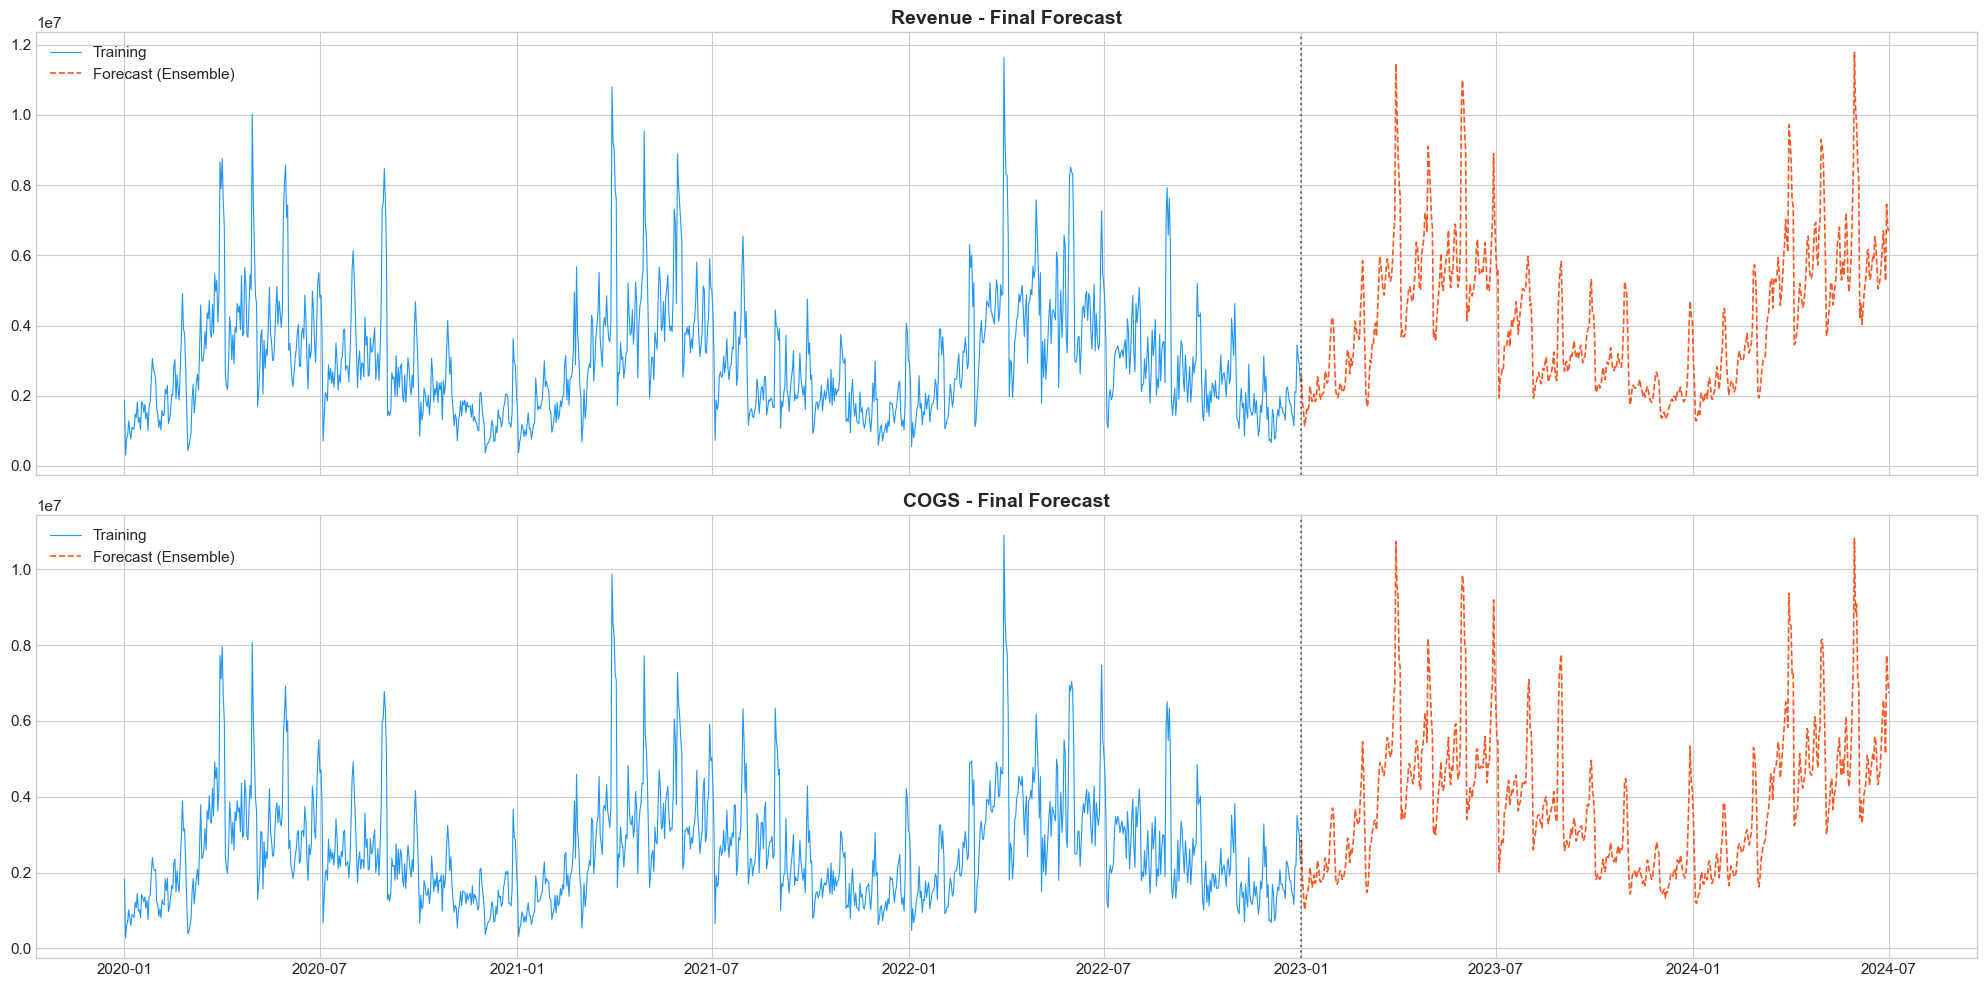

In [47]:
forecast_dates = submission_template['Date']
train_recent = sales[sales['Date'] >= '2020-01-01']

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
axes[0].plot(train_recent['Date'], train_recent['Revenue'], label='Training', color='#2196F3', linewidth=0.8)
axes[0].plot(forecast_dates, final_rev, label='Forecast (Ensemble)', color='#FF5722', linewidth=1.2, linestyle='--')
axes[0].axvline(pd.Timestamp('2023-01-01'), color='black', linestyle=':', alpha=0.5)
axes[0].set_title('Revenue - Final Forecast', fontweight='bold', fontsize=14)
axes[0].legend()
axes[1].plot(train_recent['Date'], train_recent['COGS'], label='Training', color='#2196F3', linewidth=0.8)
axes[1].plot(forecast_dates, final_cogs, label='Forecast (Ensemble)', color='#FF5722', linewidth=1.2, linestyle='--')
axes[1].axvline(pd.Timestamp('2023-01-01'), color='black', linestyle=':', alpha=0.5)
axes[1].set_title('COGS - Final Forecast', fontweight='bold', fontsize=14)
axes[1].legend()
plt.tight_layout()
plt.show()

### 10.3 Generate Submission

In [48]:
submission_df = submission_template.copy()
submission_df['Revenue'] = final_rev
submission_df['COGS'] = final_cogs

print('=== Submission Sanity Checks ===')
print(f'Shape: {submission_df.shape}')
print(f'Date range: {submission_df["Date"].min().date()} -> {submission_df["Date"].max().date()}')
print(f'Revenue - min: {submission_df["Revenue"].min():,.0f}, max: {submission_df["Revenue"].max():,.0f}')
print(f'COGS    - min: {submission_df["COGS"].min():,.0f}, max: {submission_df["COGS"].max():,.0f}')
print(f'Any NaN? {submission_df.isnull().any().any()}')
print(f'Any negative? Rev={(submission_df["Revenue"]<0).sum()}, COGS={(submission_df["COGS"]<0).sum()}')

SUBMISSION_PATH = '../submissions/submission_forecast.csv'
submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f'\n Submission saved to: {SUBMISSION_PATH}')

=== Submission Sanity Checks ===
Shape: (548, 3)
Date range: 2023-01-01 -> 2024-07-01
Revenue - min: 1,143,817, max: 11,780,336
COGS    - min: 1,020,827, max: 10,813,515
Any NaN? False
Any negative? Rev=0, COGS=0

 Submission saved to: ../submissions/submission_forecast.csv


### 10.4 Pipeline Summary

Pipeline này có thể được gói thành **công thức 4 bước** dùng cho nhiều bài toán forecasting horizon dài:

1. **Nhận diện regime và mùa vụ** - vẽ timeline, phân vùng, kiểm tra tính ổn định seasonality
2. **Xây feature calendar thuần** - Fourier, Tet/holidays, promo schedule, edge-of-month
3. **Ensemble đa họ** - 3 họ khác nhau (tuyến tính + cây + phân rã) + blend nội bộ + calibration riêng
4. **Specialist cho segment lệch nhất** - Q-specialist cho quý có sai số cao bất thường

In [49]:
print('\n' + '='*70)
print('PIPELINE COMPLETE - Tiered Ensemble Forecasting')
print('='*70)
print(f'  Features     : Calendar-only ({len(FEATURE_COLS)} features, NO lags)')
print(f'  Models       : Ridge + LightGBM (era-weighted) + Prophet + 4 Q-Specialists')
print(f'  Ensemble     : 3-tier (LGB blend -> 3-family -> calibration)')
print(f'  Tier 1       : α={ALPHA} (specialist fraction)')
print(f'  Tier 2       : Ridge={W_RIDGE}, Prophet={W_PROPHET}, LGB={W_LGB}')
print(f'  Tier 3       : CR={CR}, CC={CC}')
print(f'  Training     : Log-space, era-weight (2014-18 = 1.0, rest = 0.01)')
print(f'  Forecast     : {len(submission_df)} days (2023-01-01 -> 2024-07-01)')
print(f'  Submission   : {SUBMISSION_PATH}')
print('='*70)


PIPELINE COMPLETE - Tiered Ensemble Forecasting
  Features     : Calendar-only (81 features, NO lags)
  Models       : Ridge + LightGBM (era-weighted) + Prophet + 4 Q-Specialists
  Ensemble     : 3-tier (LGB blend -> 3-family -> calibration)
  Tier 1       : α=0.6 (specialist fraction)
  Tier 2       : Ridge=0.1, Prophet=0.1, LGB=0.8
  Tier 3       : CR=1.26, CC=1.32
  Training     : Log-space, era-weight (2014-18 = 1.0, rest = 0.01)
  Forecast     : 548 days (2023-01-01 -> 2024-07-01)
  Submission   : ../submissions/submission_forecast.csv


---
<a id='11'></a>
## 11. Sơ đồ luồng dữ liệu (Data Flow Diagram)

Để có cái nhìn tổng quan toàn hệ thống về kiến trúc dự báo của VinDatathon 2026, chúng ta sẽ mô hình hoá đường đi của dữ liệu từ lúc là dữ liệu thô (Raw Data) cho đến khi ra được kết quả đệ trình cuối cùng (Submission).

Sơ đồ sử dụng thư viện `graphviz` để trực quan hoá:
- **Input Layer**: Dữ liệu thô và Lịch.
- **Feature Engineering**: Quá trình tạo đặc trưng thời gian, lễ tết, khuyến mãi (không dùng lag).
- **Modeling Layer (Base Models)**: 3 mô hình học máy chạy song hướng cùng hệ thống mô hình chuyên gia theo quý (Q-Specialists).
- **Ensemble & Post-Processing**: Quá trình kết hợp (Blending) bằng trọng số và hiệu chỉnh độ lệch (Calibration).

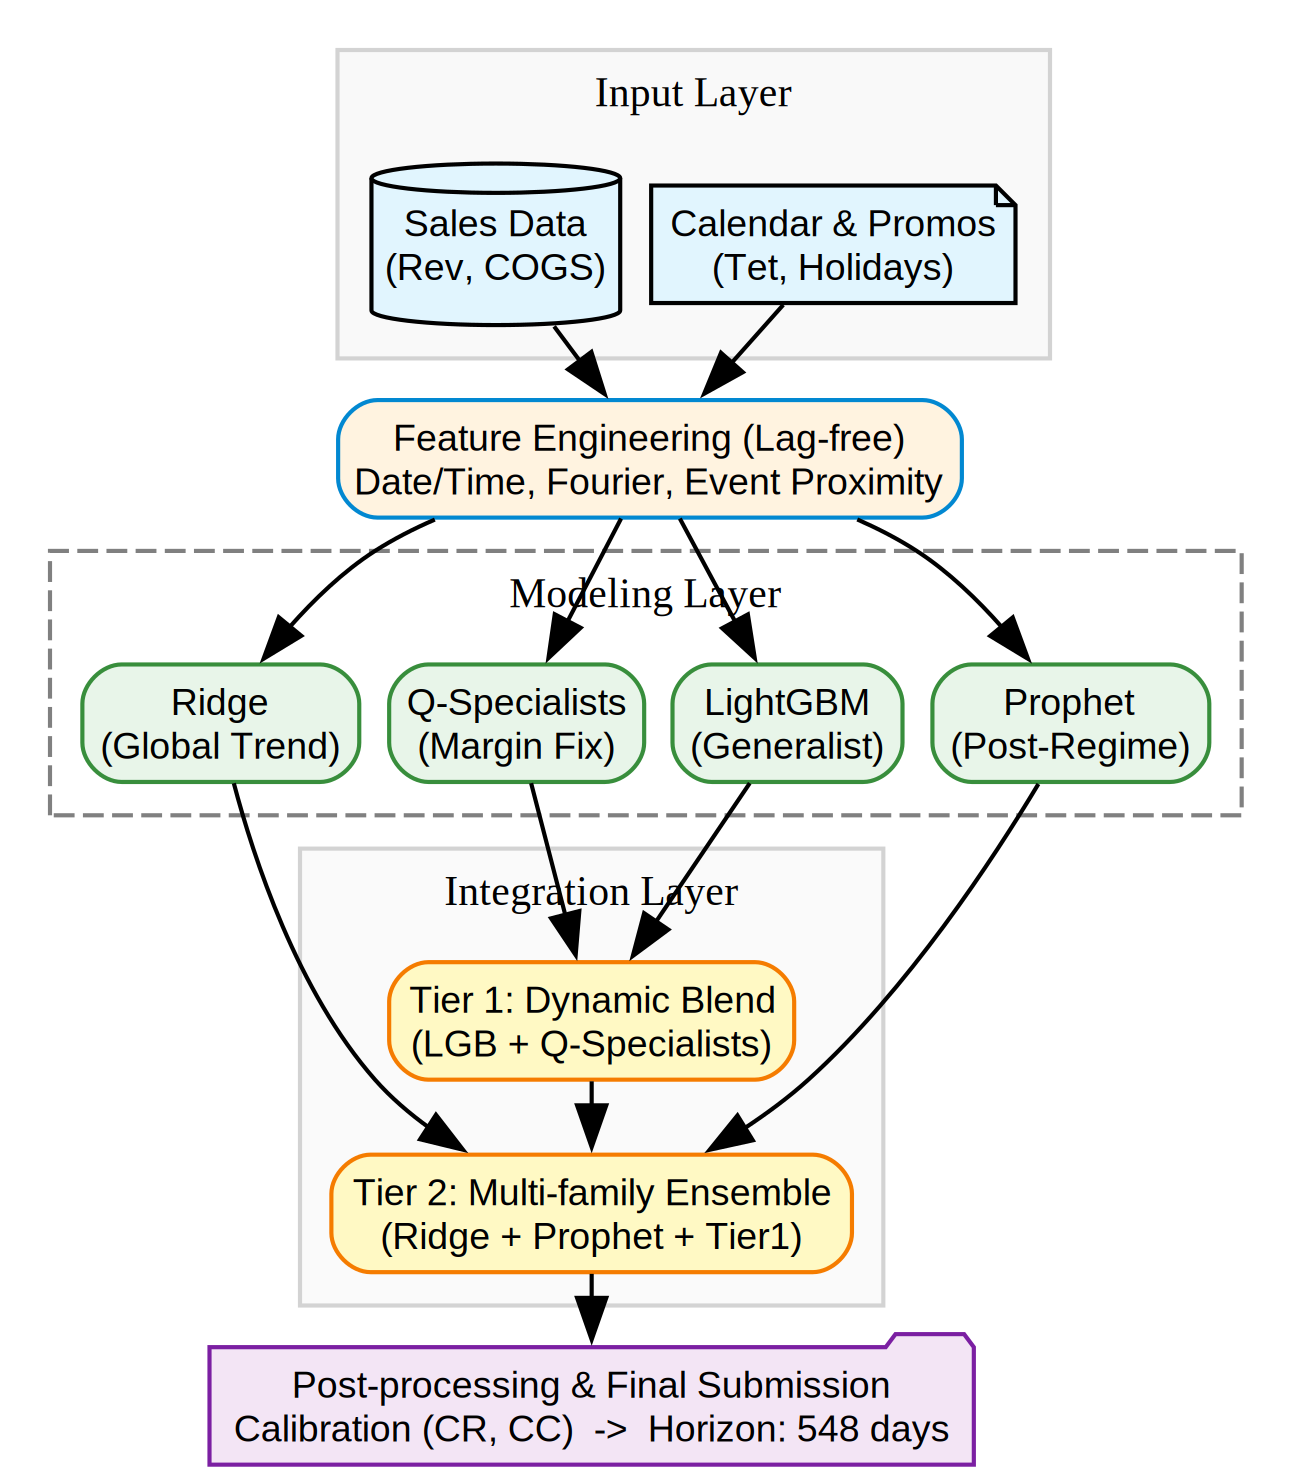

In [50]:
import graphviz
from IPython.display import display

dot = graphviz.Digraph(name='Forecasting_Data_Flow', format='png')

# Tối ưu khoảng cách dọc (ranksep) và ngang (nodesep) để nén hình
dot.attr(rankdir='TB', ranksep='0.25', nodesep='0.1', dpi='300')
dot.attr('node', fontname='Arial', fontsize='9', margin='0.05,0.05', height='0.3')

# 1. Lớp Dữ liệu đầu vào
with dot.subgraph(name='cluster_input') as c:
    c.attr(label='Input Layer', style='filled', fillcolor='#f9f9f9', color='lightgrey', fontsize='10')
    c.attr(rank='same') # Ép các node nằm trên cùng 1 đường ngang thẳng tắp
    c.node('RawData', 'Sales Data\n(Rev, COGS)', shape='cylinder', style='filled', fillcolor='#e1f5fe')
    c.node('Calendar', 'Calendar & Promos\n(Tet, Holidays)', shape='note', style='filled', fillcolor='#e1f5fe')

# 2. Lớp Feature Engineering
dot.node('FE', 'Feature Engineering (Lag-free)\nDate/Time, Fourier, Event Proximity', 
         shape='box', style='filled,rounded', fillcolor='#fff3e0', color='#0288d1')

# 3. Lớp Mô hình (Song song)
with dot.subgraph(name='cluster_models') as c:
    c.attr(label='Modeling Layer', style='dashed', color='gray', fontsize='10')
    c.node('M1', 'Ridge\n(Global Trend)', shape='box', style='filled,rounded', fillcolor='#e8f5e9', color='#388e3c')
    c.node('M2', 'LightGBM\n(Generalist)', shape='box', style='filled,rounded', fillcolor='#e8f5e9', color='#388e3c')
    c.node('M3', 'Prophet\n(Post-Regime)', shape='box', style='filled,rounded', fillcolor='#e8f5e9', color='#388e3c')
    c.node('M4', 'Q-Specialists\n(Margin Fix)', shape='box', style='filled,rounded', fillcolor='#e8f5e9', color='#388e3c')

# 4. Lớp Ensemble
with dot.subgraph(name='cluster_ensemble') as c:
    c.attr(label='Integration Layer', style='filled', fillcolor='#fafafa', color='lightgrey', fontsize='10')
    c.node('E1', 'Tier 1: Dynamic Blend\n(LGB + Q-Specialists)', shape='box', style='filled,rounded', fillcolor='#fff9c4', color='#f57c00')
    c.node('E2', 'Tier 2: Multi-family Ensemble\n(Ridge + Prophet + Tier1)', shape='box', style='filled,rounded', fillcolor='#fff9c4', color='#f57c00')

# 5. Gộp Post-Processing & Output để tiết kiệm 1 tầng chiều dọc
dot.node('Output', 'Post-processing & Final Submission\nCalibration (CR, CC)  ->  Horizon: 548 days', 
         shape='folder', style='filled', fillcolor='#f3e5f5', color='#7b1fa2')

# --- KẾT NỐI (EDGES) ---
dot.edge('RawData', 'FE')
dot.edge('Calendar', 'FE')

for m in ['M1', 'M2', 'M3', 'M4']:
    dot.edge('FE', m)

dot.edge('M2', 'E1')
dot.edge('M4', 'E1')
dot.edge('M1', 'E2')
dot.edge('M3', 'E2')
dot.edge('E1', 'E2')

dot.edge('E2', 'Output')

# Xuất ra file architecture.png để chèn vào LaTeX
dot.render('architecture', format='png', cleanup=True)
display(dot)